# 1. Libraries

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # This must be set BEFORE importing TF

import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import activations as activations
from keras import applications as applications
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
import time
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 2. Get Data

## Climate Data Time-Series

Dataset used for this mini-project is Jena Climate dataset recorded by the
[Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/wetter/).
The dataset consists of 14 features recorded once per 10 minutes.

**Location**: Weather Station, Max Planck Institute for Biogeochemistry
in Jena, Germany

**Time-frame Considered**: Jan 10, 2009 - December 31, 2016


The table below shows the column names, their value formats, and their description.

Index| Features      |Format             |Description
-----|---------------|-------------------|-----------------------
1    |Date Time      |01.01.2009 00:10:00|Date-time reference
2    |p (mbar)       |996.52             |The pascal SI derived unit of pressure used to quantify internal pressure. Meteorological reports typically state atmospheric pressure in millibars.
3    |T (degC)       |-8.02              |Temperature in Celsius
4    |Tpot (K)       |265.4              |Temperature in Kelvin
5    |Tdew (degC)    |-8.9               |Temperature in Celsius relative to humidity. Dew Point is a measure of the absolute amount of water in the air, the DP is the temperature at which the air cannot hold all the moisture in it and water condenses.
6    |rh (%)         |93.3               |Relative Humidity is a measure of how saturated the air is with water vapor, the %RH determines the amount of water contained within collection objects.
7    |VPmax (mbar)   |3.33               |Saturation vapor pressure
8    |VPact (mbar)   |3.11               |Vapor pressure
9    |VPdef (mbar)   |0.22               |Vapor pressure deficit
10   |sh (g/kg)      |1.94               |Specific humidity
11   |H2OC (mmol/mol)|3.12               |Water vapor concentration
12   |rho (g/m ** 3) |1307.75            |Airtight
13   |wv (m/s)       |1.03               |Wind speed
14   |max. wv (m/s)  |1.75               |Maximum wind speed
15   |wd (deg)       |152.3              |Wind direction in degrees

In [2]:
"""
from zipfile import ZipFile

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
"""

csv_path = "../dataset/jena_climate_2009_2016.csv"
df = pd.read_csv(csv_path)

# Fix sensor error codes: -9999.0 in wind speed columns are equipment failures
# (18 rows in wv, 20 rows in max.wv — all from 2015-07-13 09:00–12:00).
# Replace with NaN so hourly .mean() resampling ignores them instead of
# producing values ~5000 std devs from the mean.
df[["wv (m/s)", "max. wv (m/s)"]] = df[["wv (m/s)", "max. wv (m/s)"]].replace(-9999.0, np.nan)

In [3]:
# Convert string to a proper DateTime so that
# matplotlib and the other components won't have to do it on every time
# Also, the date format in the CSV is European: DD.MM.YYYY HH:MM:SS (day comes first)
# Fix that by specifying the format explicitly:
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")

In [4]:
df.head(5)

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


# 3. Data Understanding and Exploration

## 3.1 Dataset Shape and Types

In [5]:
df.shape , df.dtypes
print('\nDataset Shape is:', df.shape)
print('\nDataset Types are:', df.dtypes)


Dataset Shape is: (420551, 15)

Dataset Types are: Date Time          datetime64[us]
p (mbar)                  float64
T (degC)                  float64
Tpot (K)                  float64
Tdew (degC)               float64
rh (%)                    float64
VPmax (mbar)              float64
VPact (mbar)              float64
VPdef (mbar)              float64
sh (g/kg)                 float64
H2OC (mmol/mol)           float64
rho (g/m**3)              float64
wv (m/s)                  float64
max. wv (m/s)             float64
wd (deg)                  float64
dtype: object


## 3.2 Nan Values

In [6]:
df.isnull().sum() 

Date Time           0
p (mbar)            0
T (degC)            0
Tpot (K)            0
Tdew (degC)         0
rh (%)              0
VPmax (mbar)        0
VPact (mbar)        0
VPdef (mbar)        0
sh (g/kg)           0
H2OC (mmol/mol)     0
rho (g/m**3)        0
wv (m/s)           18
max. wv (m/s)      20
wd (deg)            0
dtype: int64

## 3.3 Check Duplicated Values

In [7]:
df.duplicated().sum()

np.int64(327)

## 3.4 Descriptive Stats 

In [8]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
p (mbar),420551.0,989.212776,8.358481,913.60,984.20,989.58,994.72,1015.35
T (degC),420551.0,9.450147,8.423365,-23.01,3.36,9.42,15.47,37.28
Tpot (K),420551.0,283.492743,8.504471,250.60,277.43,283.47,289.53,311.34
Tdew (degC),420551.0,4.955854,6.730674,-25.01,0.24,5.22,10.07,23.11
rh (%),420551.0,76.008259,16.476175,12.95,65.21,79.30,89.40,100.00
VPmax (mbar),420551.0,13.576251,7.739020,0.95,7.78,11.82,17.60,63.77
VPact (mbar),420551.0,9.533756,4.184164,0.79,6.21,8.86,12.35,28.32
VPdef (mbar),420551.0,4.042412,4.896851,0.00,0.87,2.19,5.30,46.01
sh (g/kg),420551.0,6.022408,2.656139,0.50,3.92,5.59,7.80,18.13
H2OC (mmol/mol),420551.0,9.640223,4.235395,0.80,6.29,8.96,12.49,28.82


### 3.4.1 Variables Overview

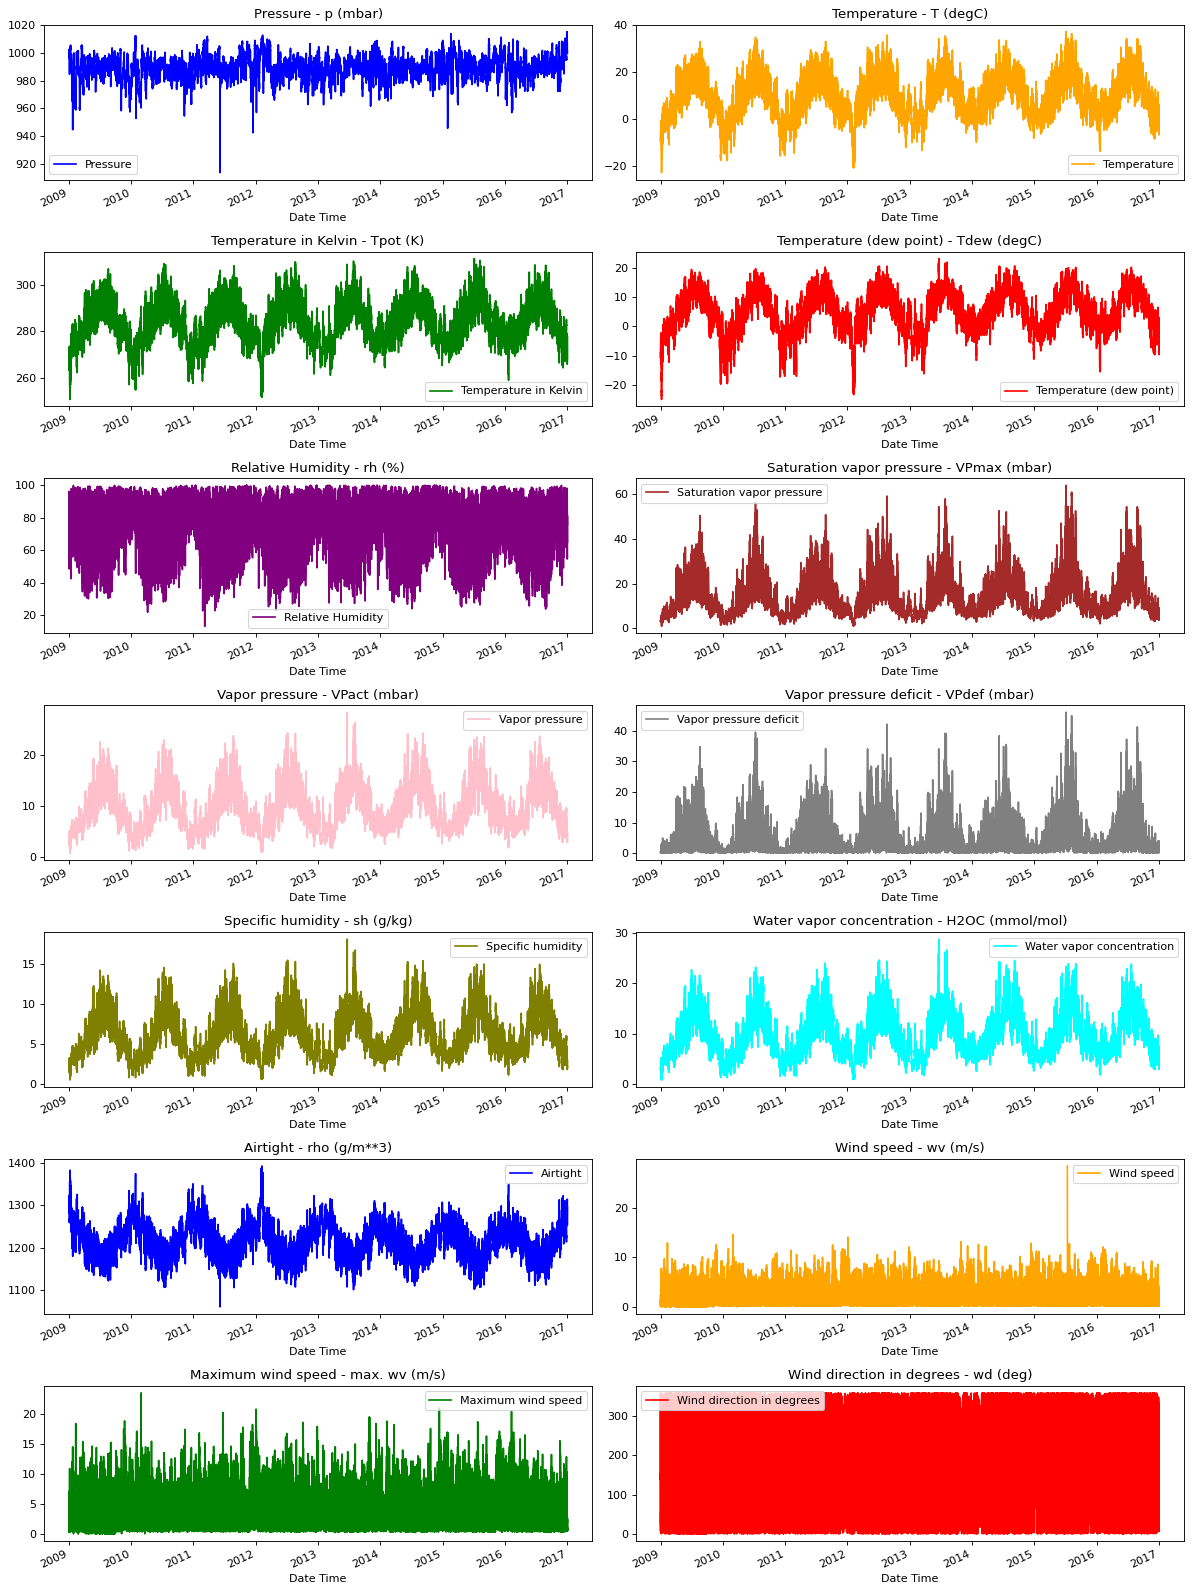

In [9]:
titles = [
    "Pressure",
    "Temperature",
    "Temperature in Kelvin",
    "Temperature (dew point)",
    "Relative Humidity",
    "Saturation vapor pressure",
    "Vapor pressure",
    "Vapor pressure deficit",
    "Specific humidity",
    "Water vapor concentration",
    "Airtight",
    "Wind speed",
    "Maximum wind speed",
    "Wind direction in degrees",
]

feature_keys = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",
]

colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]

date_time_key = "Date Time"


def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(
        nrows=7, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        t_data = data[key]
        t_data.index = time_data
        t_data.head()
        ax = t_data.plot(
            ax=axes[i // 2, i % 2],
            color=c,
            title="{} - {}".format(titles[i], key),
            rot=25,
        )
        ax.legend([titles[i]])
    plt.tight_layout()


show_raw_visualization(df)


## 3.5 Numeric Analysis

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)
print("Total numeric:", len(num_cols))

Numeric columns: ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Total numeric: 14


### 3.5.1 Variables Histograms 

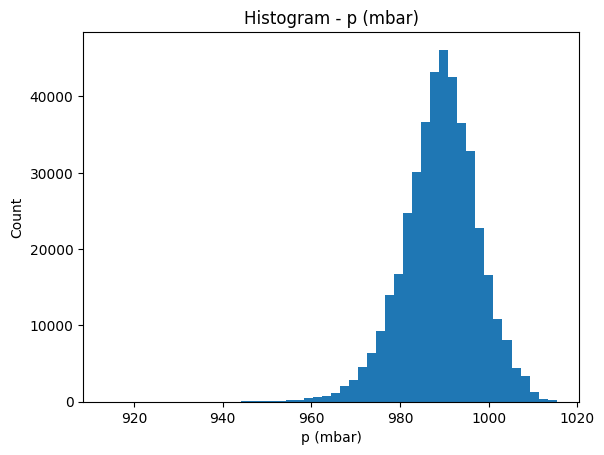

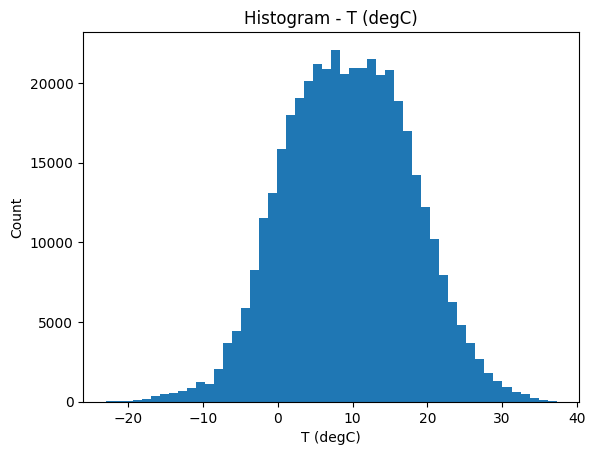

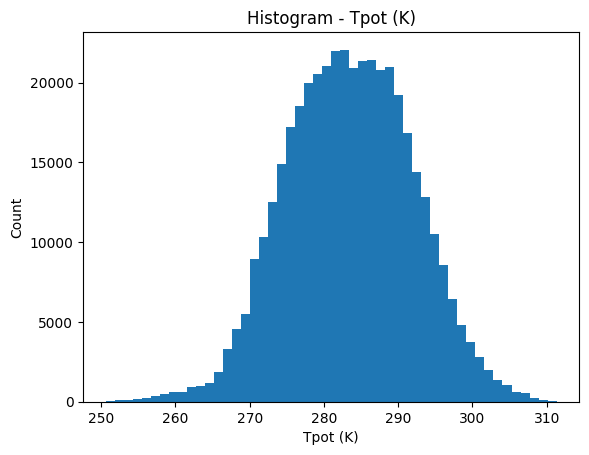

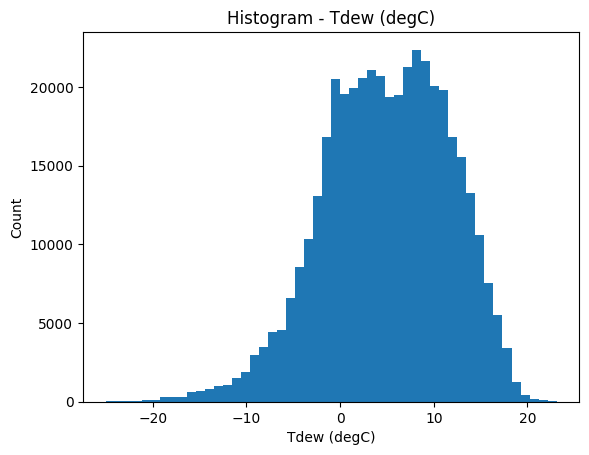

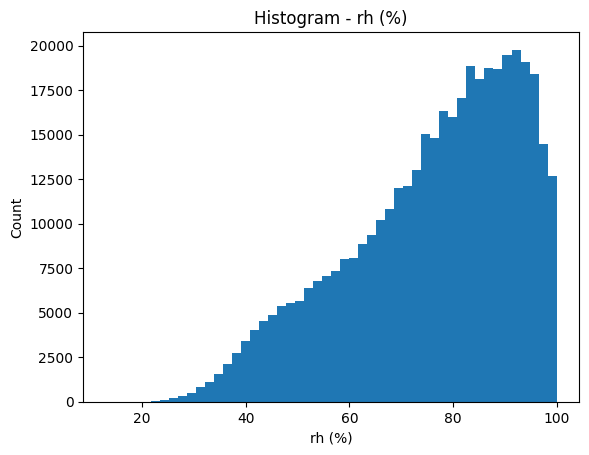

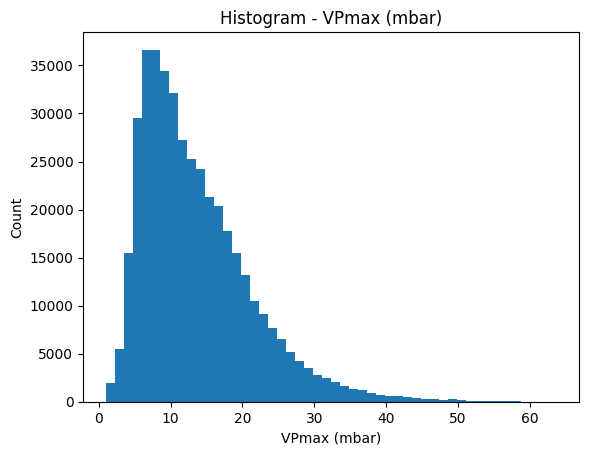

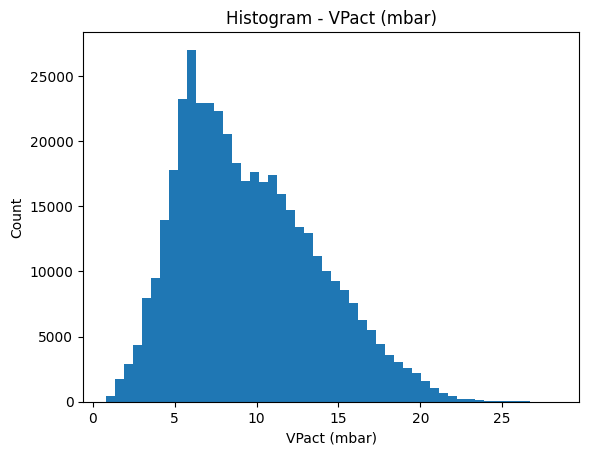

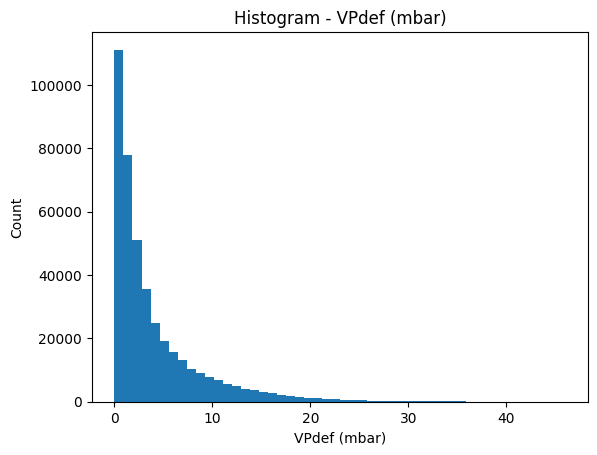

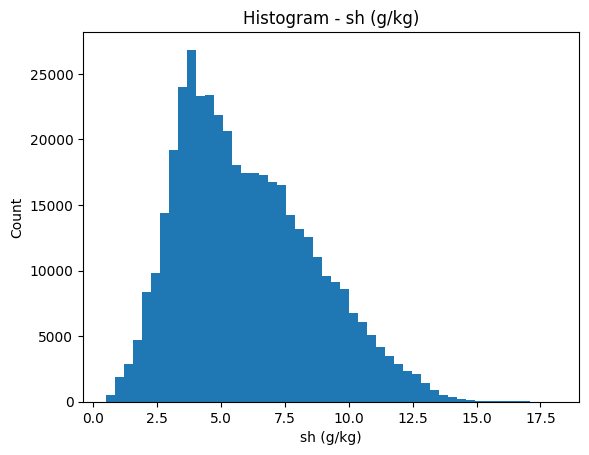

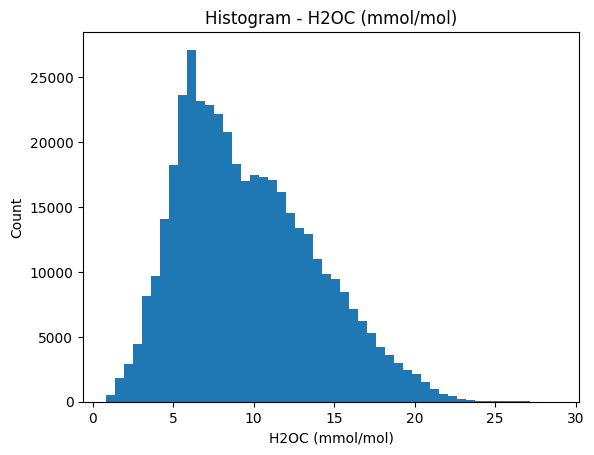

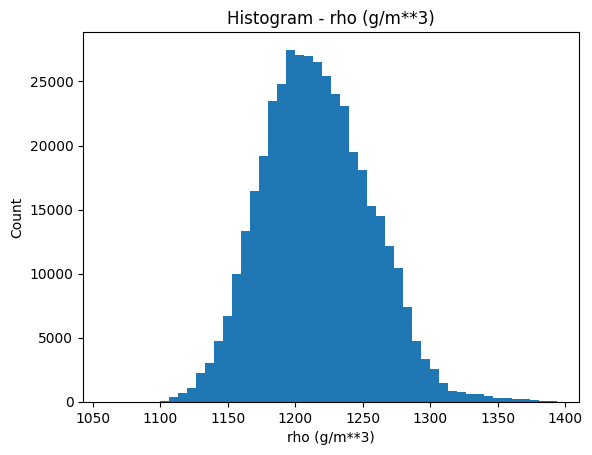

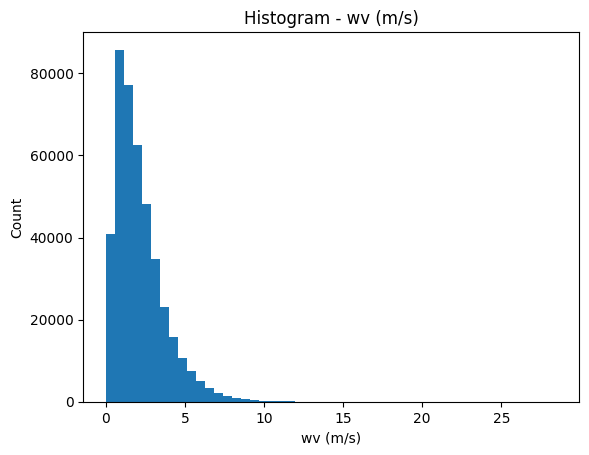

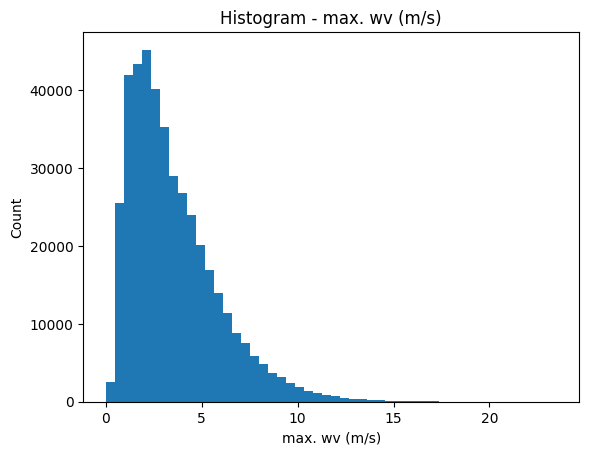

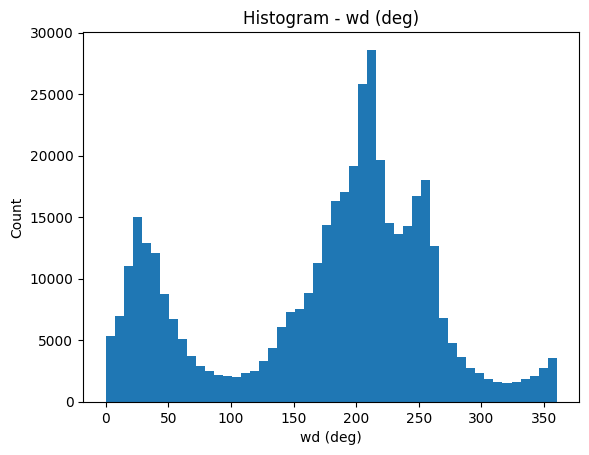

In [11]:
for c in num_cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins=50)
    plt.title(f"Histogram - {c}")
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.show()

### 3.5.2 Boxplots

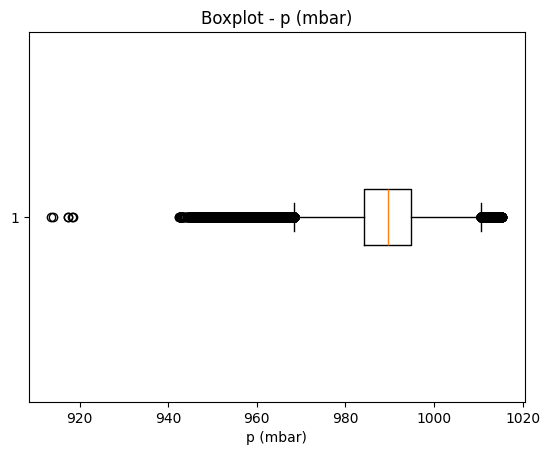

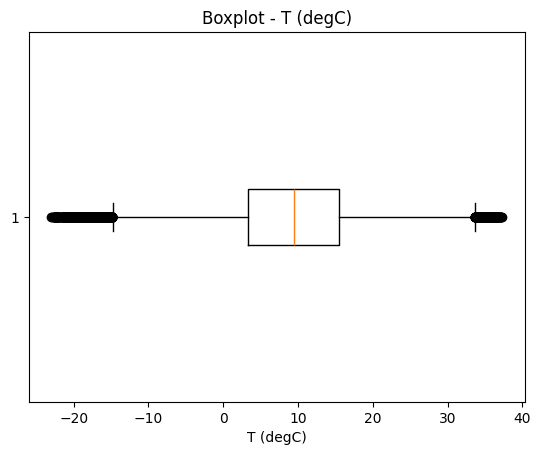

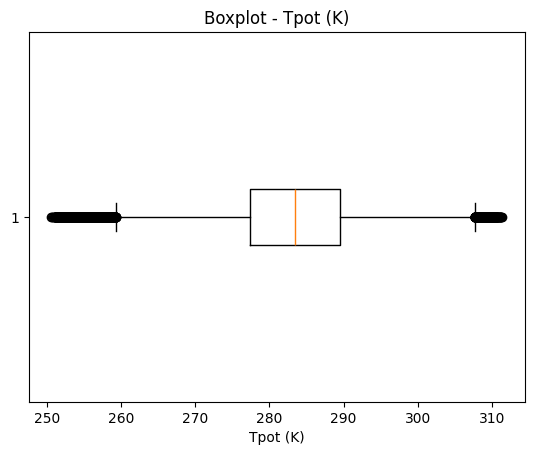

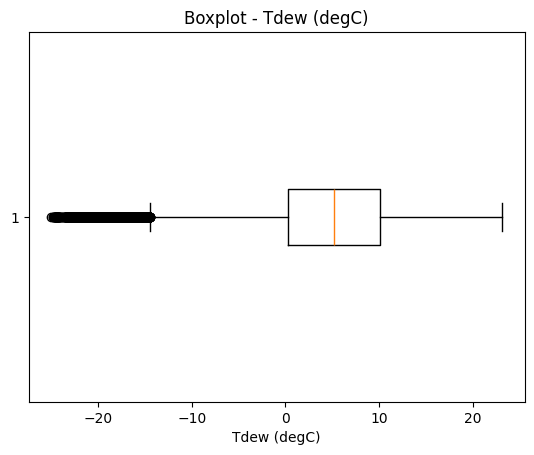

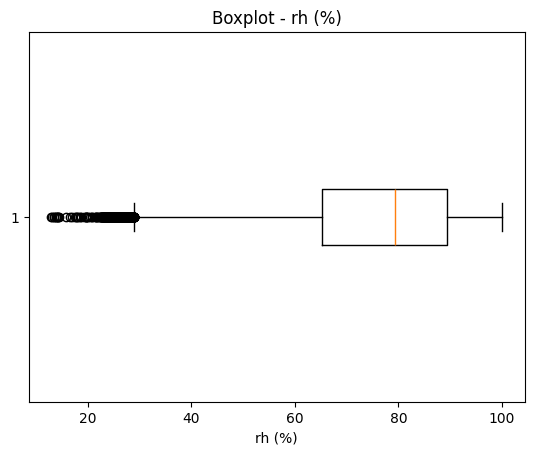

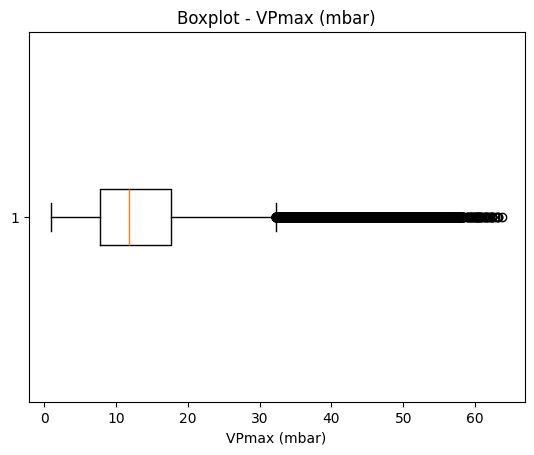

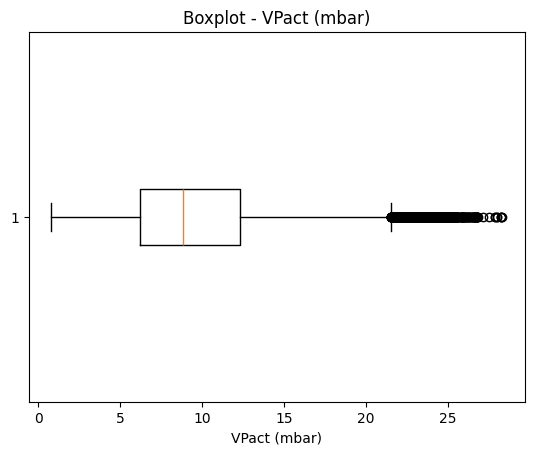

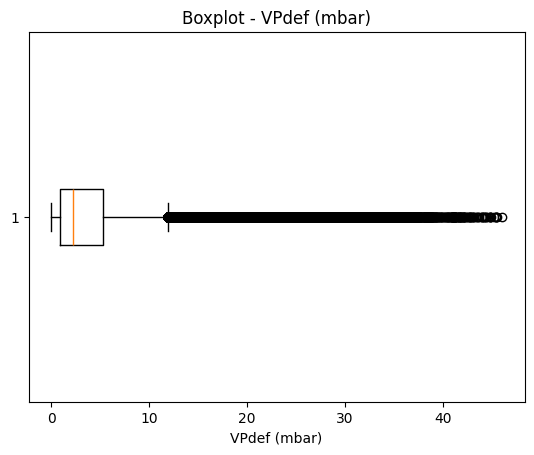

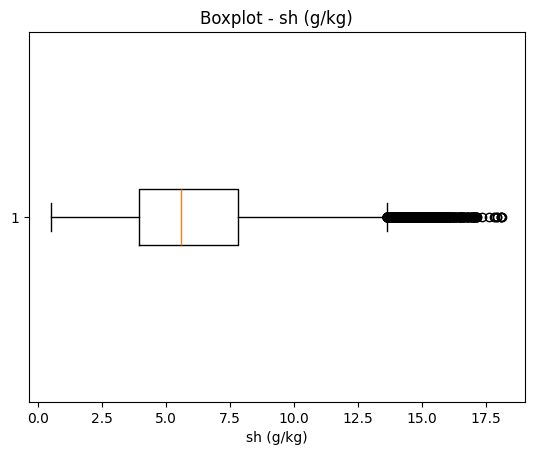

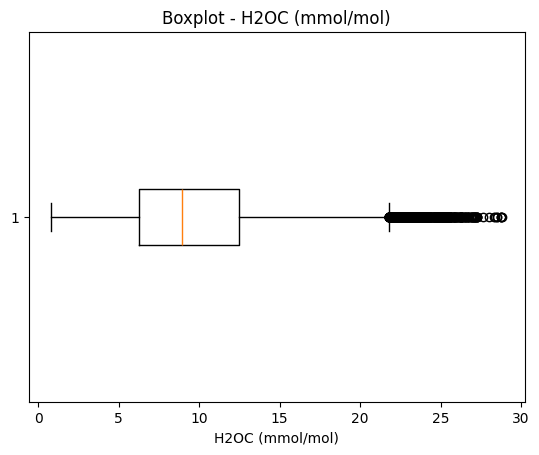

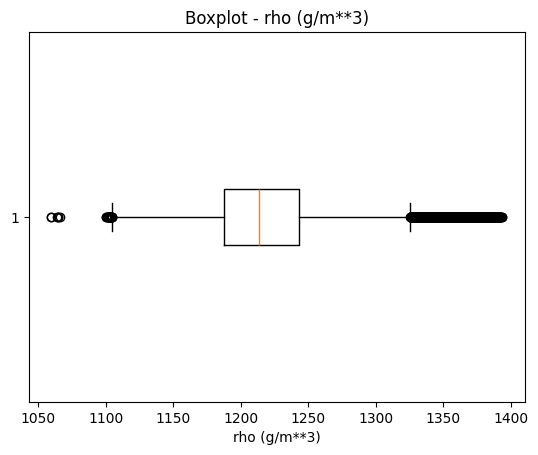

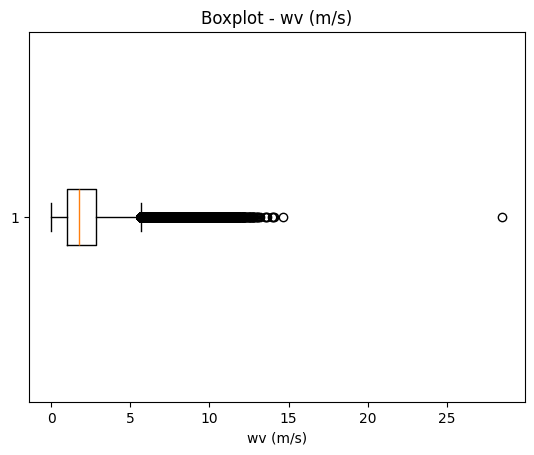

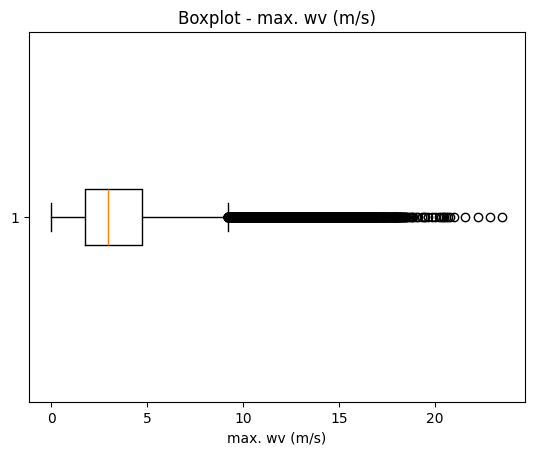

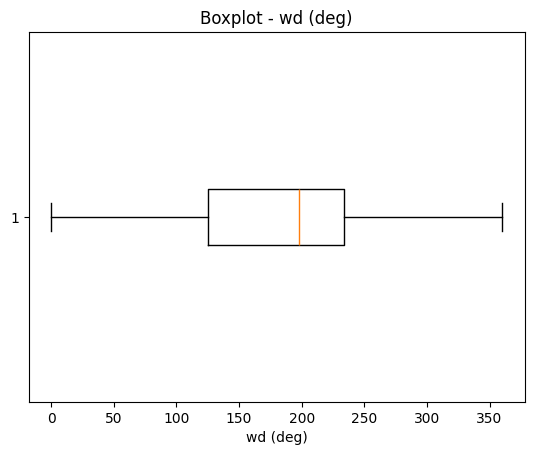

In [12]:
for c in num_cols:
    plt.figure()
    plt.boxplot(df[c].dropna(), vert=False)
    plt.title(f"Boxplot - {c}")
    plt.xlabel(c)
    plt.show()

### 3.5.3 Outliers Detection

In [13]:
outlier_summary = []

for c in num_cols:
    s = df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    outlier_summary.append([c, n_outliers, lower, upper])

outliers_df = pd.DataFrame(outlier_summary, columns=["col", "n_outliers", "iqr_low", "iqr_high"])
display(outliers_df.sort_values("n_outliers", ascending=False))

,col,n_outliers,iqr_low,iqr_high
7,VPdef (mbar),32347,-5.775,11.945
11,wv (m/s),14740,-1.815,5.665
12,max. wv (m/s),11761,-2.710,9.210
5,VPmax (mbar),11565,-6.950,32.330
0,p (mbar),6750,968.420,1010.500
10,rho (g/m**3),3048,1104.570,1325.690
3,Tdew (degC),2603,-14.505,24.815
2,Tpot (K),1945,259.280,307.680
1,T (degC),1528,-14.805,33.635
8,sh (g/kg),1439,-1.900,13.620


### 3.5.4 Correlation Between Variables

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
p (mbar),1.000000,-0.045375,-0.124718,-0.066755,-0.018352,-0.031546,-0.054370,-0.003401,-0.069762,-0.069804,0.307640,-0.209615,-0.204801,-0.063258
T (degC),-0.045375,1.000000,0.996827,0.895708,-0.572416,0.951113,0.867673,0.761744,0.866755,0.867177,-0.963410,0.088435,0.125144,0.038732
Tpot (K),-0.124718,0.996827,1.000000,0.894911,-0.567127,0.947293,0.866205,0.756962,0.866533,0.866955,-0.981345,0.104688,0.140752,0.043599
Tdew (degC),-0.066755,0.895708,0.894911,1.000000,-0.156615,0.799271,0.968344,0.435752,0.967599,0.968044,-0.885232,-0.053624,-0.036138,0.049877
rh (%),-0.018352,-0.572416,-0.567127,-0.156615,1.000000,-0.615842,-0.151494,-0.843835,-0.150841,-0.150969,0.514282,-0.312248,-0.362965,-0.015912
VPmax (mbar),-0.031546,0.951113,0.947293,0.799271,-0.615842,1.000000,0.824865,0.875588,0.824460,0.824493,-0.901536,0.092519,0.126451,-0.009583
VPact (mbar),-0.054370,0.867673,0.866205,0.968344,-0.151494,0.824865,1.000000,0.449154,0.999851,0.999856,-0.850241,-0.068835,-0.055827,0.018418
VPdef (mbar),-0.003401,0.761744,0.756962,0.435752,-0.843835,0.875588,0.449154,1.000000,0.448641,0.448689,-0.698290,0.205034,0.247544,-0.030881
sh (g/kg),-0.069762,0.866755,0.866533,0.967599,-0.150841,0.824460,0.999851,0.448641,1.000000,0.999997,-0.853325,-0.065332,-0.052480,0.019376
H2OC (mmol/mol),-0.069804,0.867177,0.866955,0.968044,-0.150969,0.824493,0.999856,0.448689,0.999997,1.000000,-0.853769,-0.065255,-0.052371,0.019607


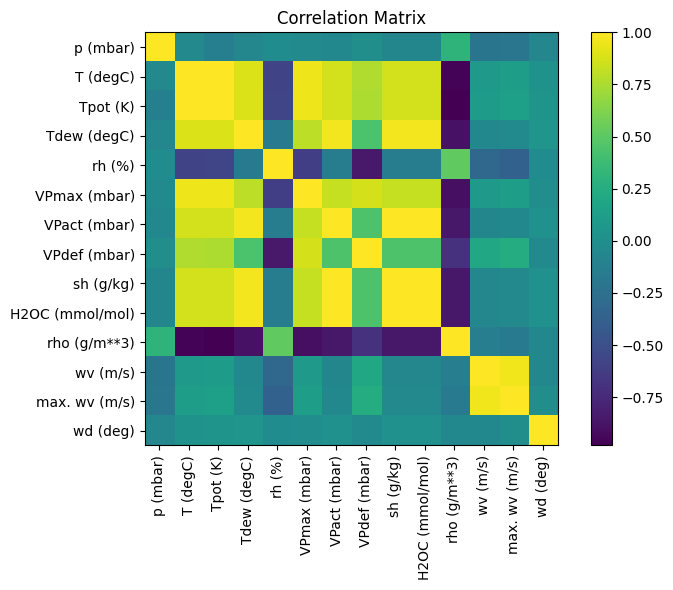

In [14]:
corr = df[num_cols].corr()

display(corr)

plt.figure(figsize=(8, 6))
plt.imshow(corr.values)
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

### 3.5.6 Target (Correlation)

T (degC)           1.000000
Tpot (K)           0.996827
VPmax (mbar)       0.951113
Tdew (degC)        0.895708
VPact (mbar)       0.867673
H2OC (mmol/mol)    0.867177
sh (g/kg)          0.866755
VPdef (mbar)       0.761744
max. wv (m/s)      0.125144
wv (m/s)           0.088435
wd (deg)           0.038732
p (mbar)          -0.045375
rh (%)            -0.572416
rho (g/m**3)      -0.963410
Name: T (degC), dtype: float64

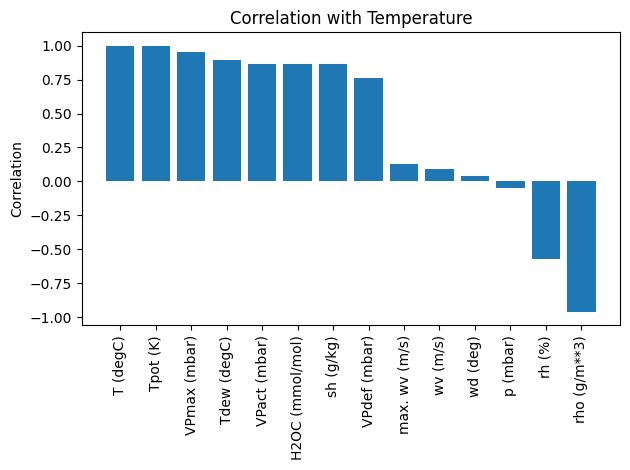

In [15]:
target = "T (degC)"
corr_target = corr[target].sort_values(ascending=False)

display(corr_target)

plt.figure()
plt.bar(corr_target.index, corr_target.values)
plt.xticks(rotation=90)
plt.title("Correlation with Temperature")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

### 3.5.7 Temporal Evolution

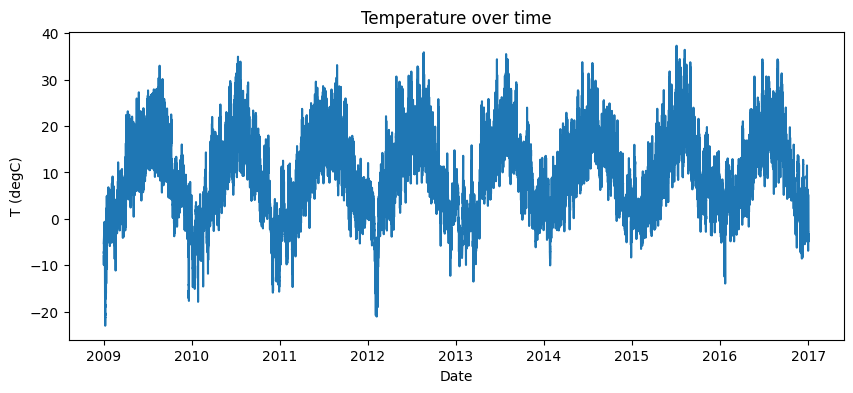

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(df["Date Time"], df["T (degC)"])
plt.title("Temperature over time")
plt.xlabel("Date")
plt.ylabel("T (degC)")
plt.show()

### 3.5.8 Mean by Day Hour

In [17]:
# Strip any accidental whitespace from column names (defensive, no-op if already clean)
df.columns = df.columns.str.strip()

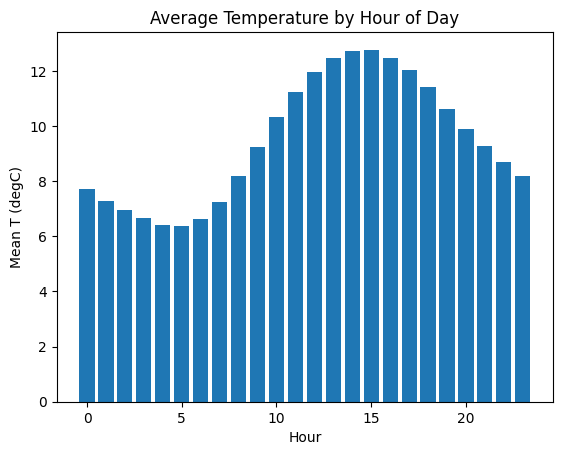

In [18]:
df["hour"] = df["Date Time"].dt.hour
hourly_mean = df.groupby("hour")["T (degC)"].mean()

plt.figure()
plt.bar(hourly_mean.index, hourly_mean.values)
plt.title("Average Temperature by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Mean T (degC)")
plt.show()

### 3.5.9 Annual Sazonality

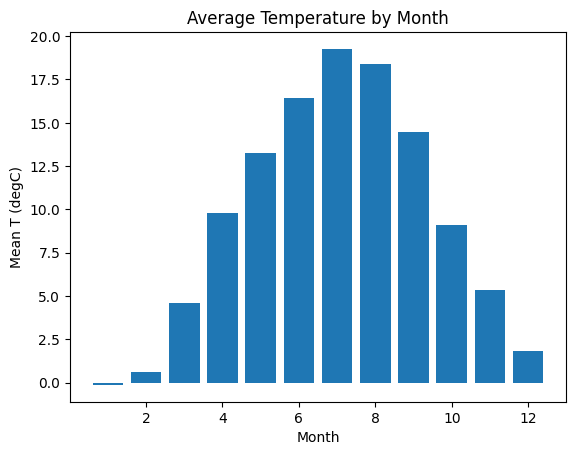

In [19]:
df["month"] = df["Date Time"].dt.month
monthly_mean = df.groupby("month")["T (degC)"].mean()

plt.figure()
plt.bar(monthly_mean.index, monthly_mean.values)
plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Mean T (degC)")
plt.show()

### 3.5.10 Target Relation with other Variables (Scatter)

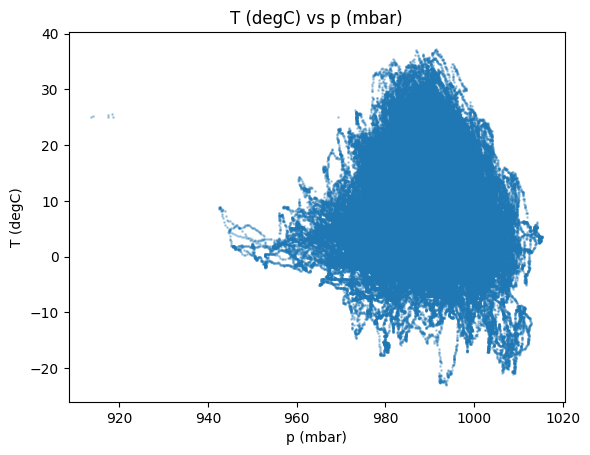

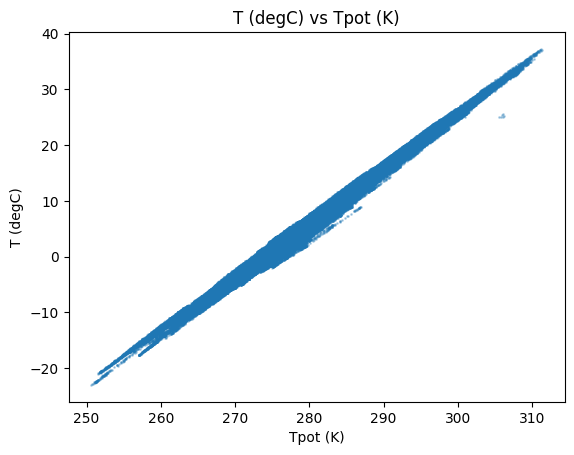

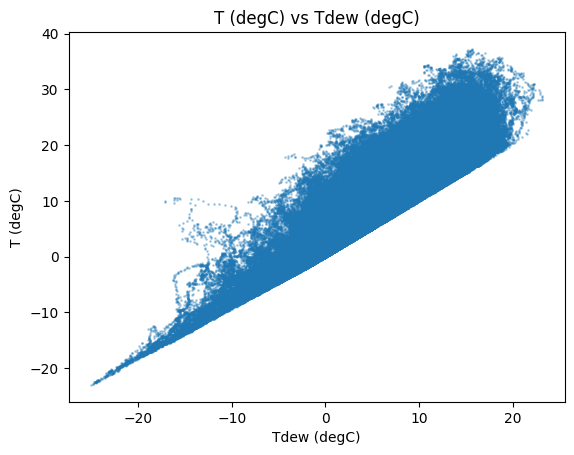

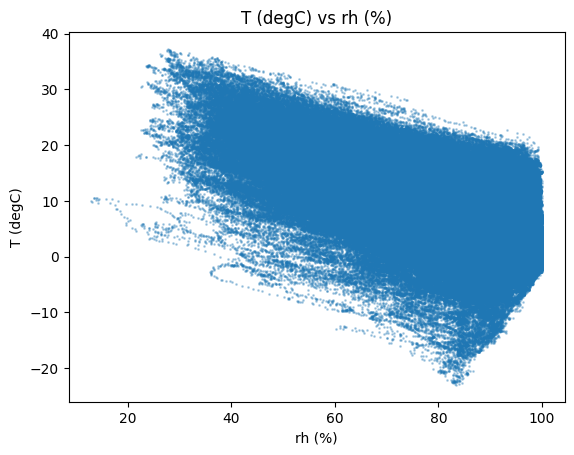

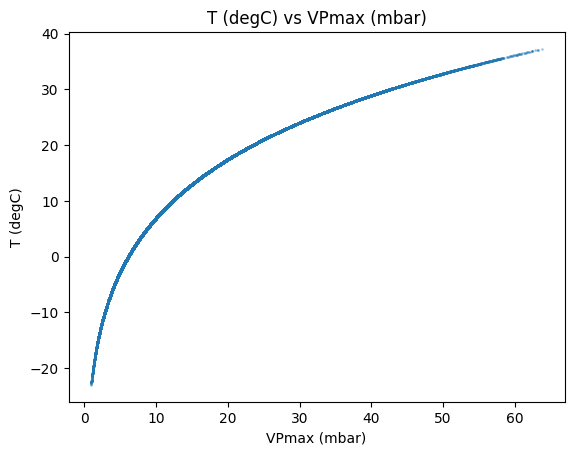

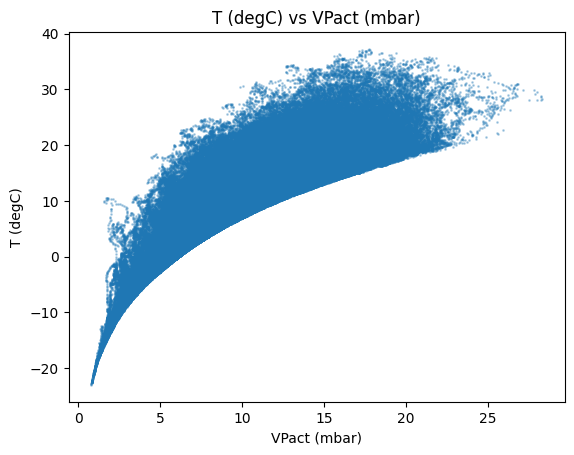

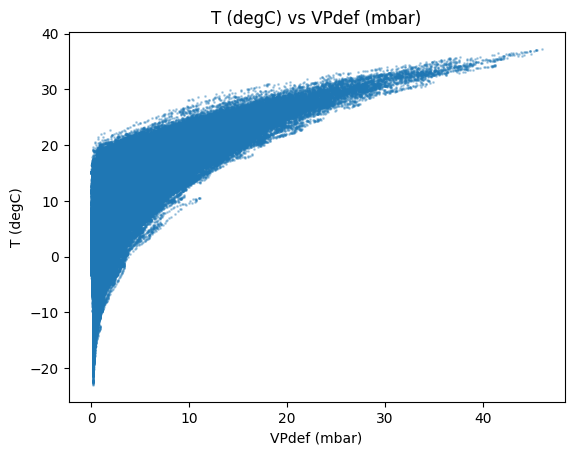

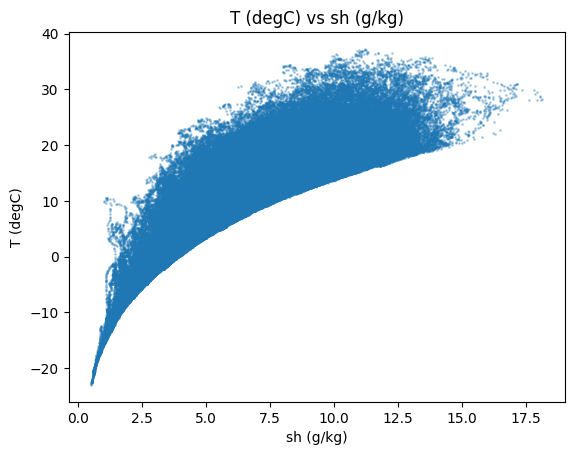

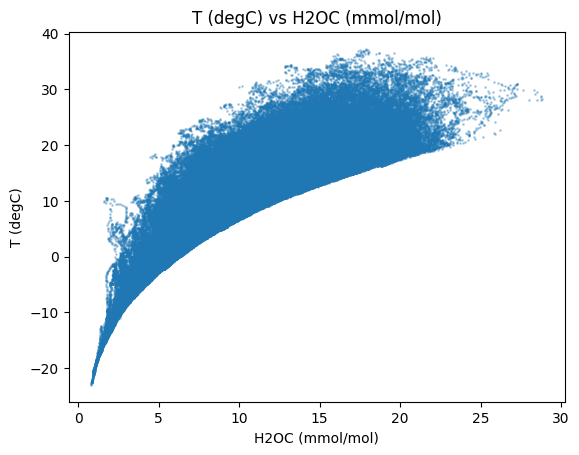

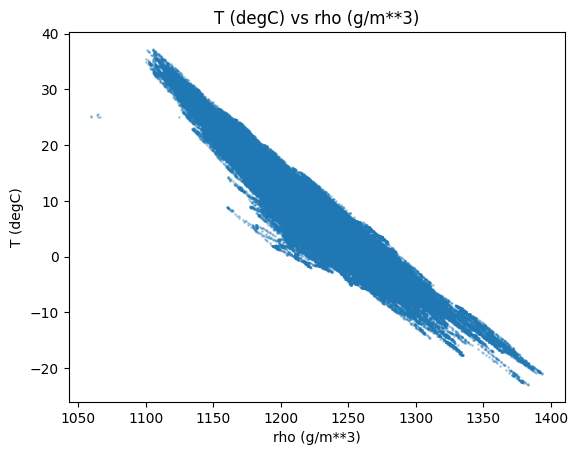

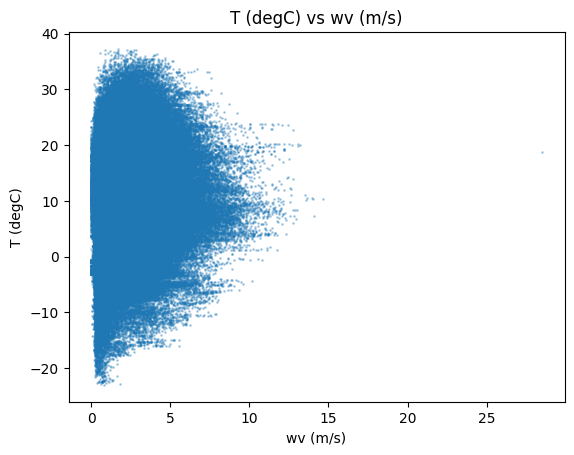

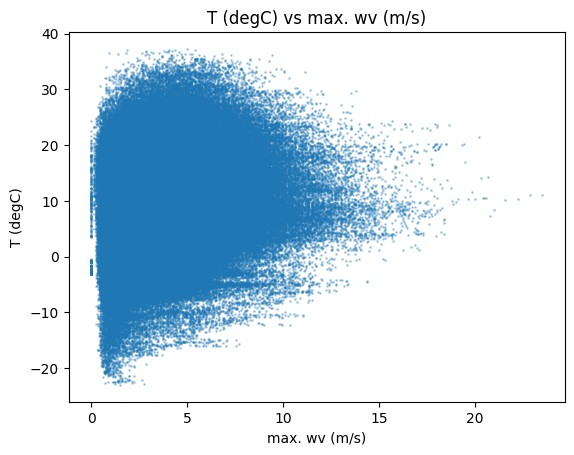

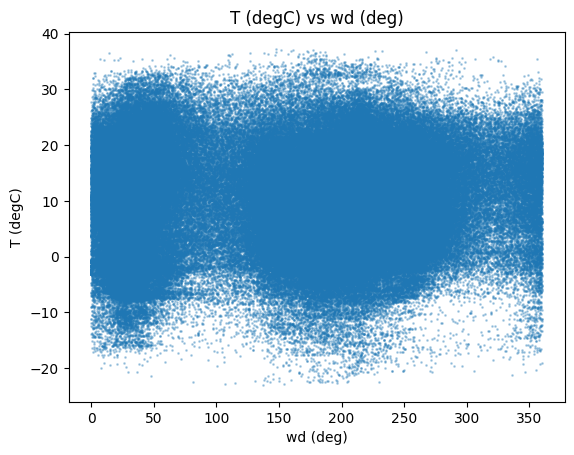

In [20]:
target = "T (degC)"
exclude = {target, "hour", "month"}
x_cols = [c for c in num_cols if c not in exclude]

for x in x_cols:
    plt.figure()
    plt.scatter(df[x], df[target], s=1, alpha=0.3)
    plt.xlabel(x)
    plt.ylabel(target)
    plt.title(f"{target} vs {x}")
    plt.show()

### 3.5.11 Target Mean by 'bins' of Variables

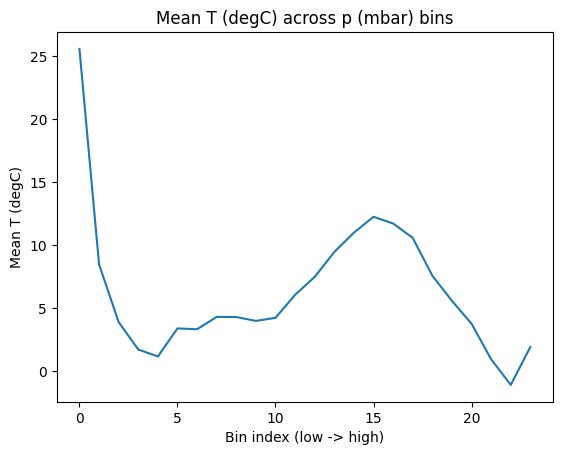

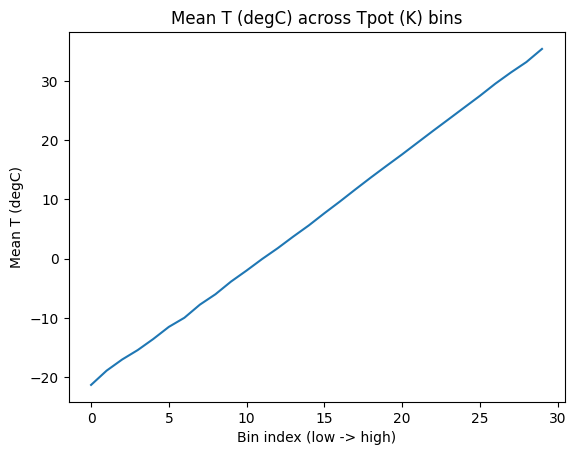

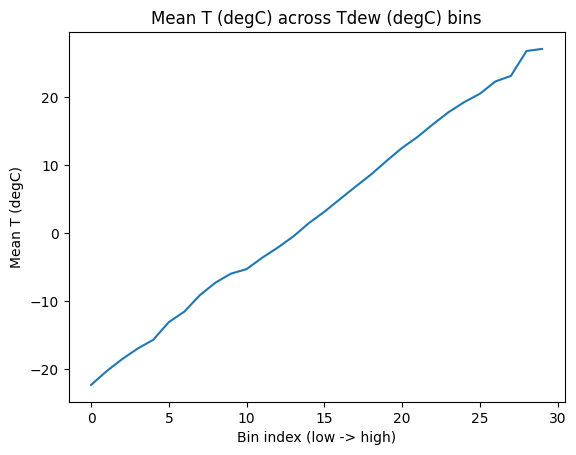

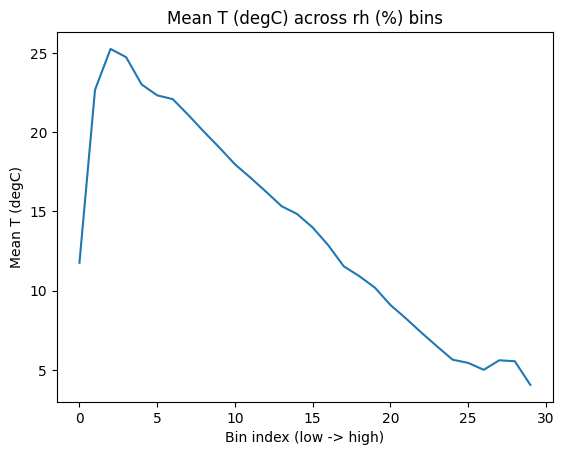

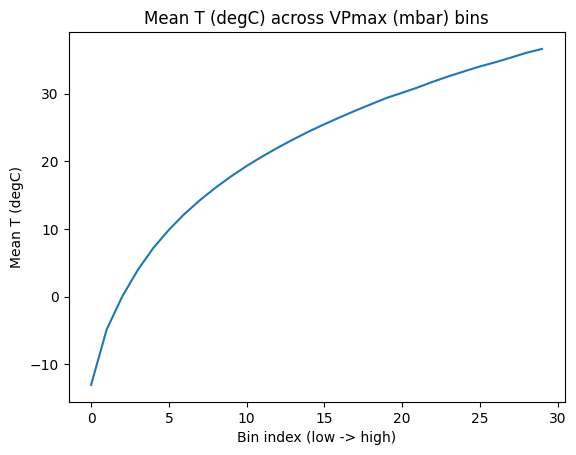

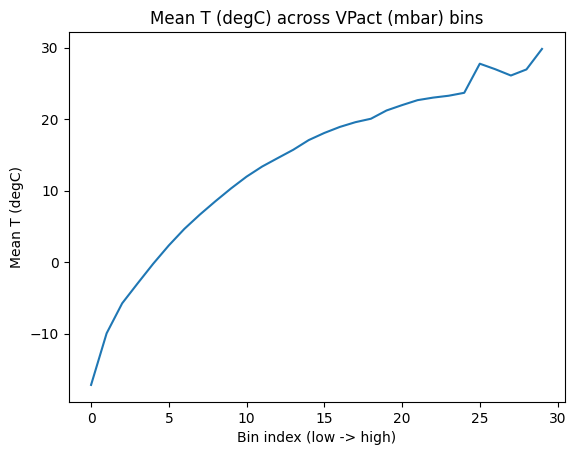

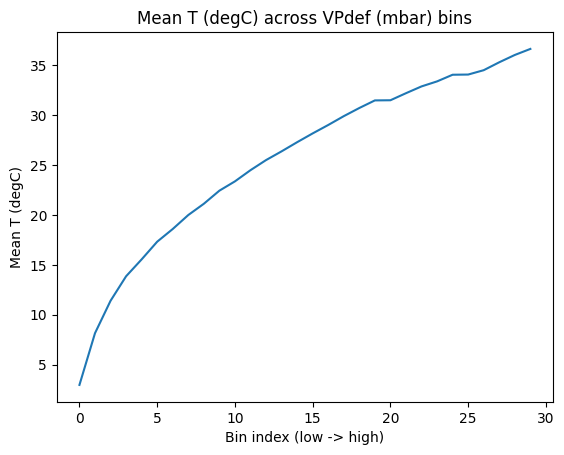

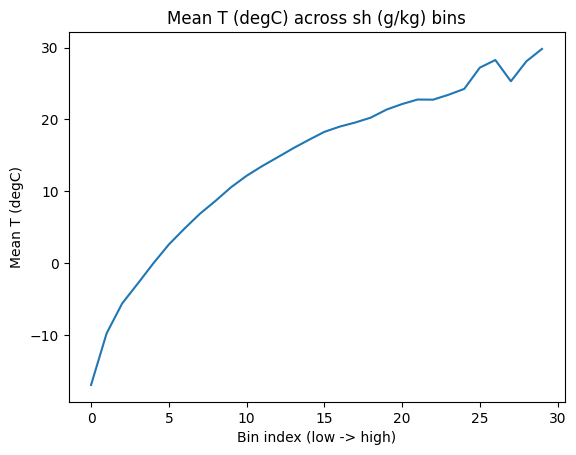

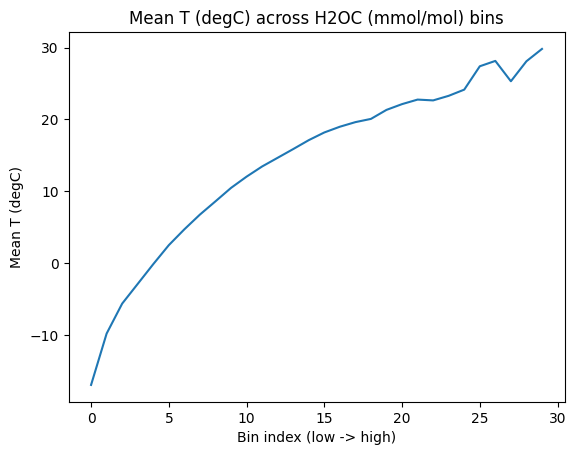

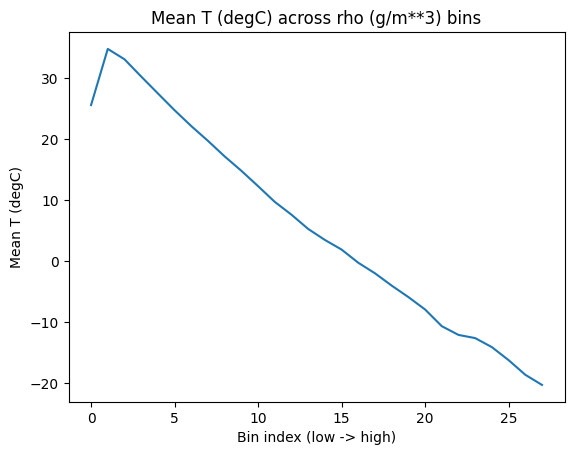

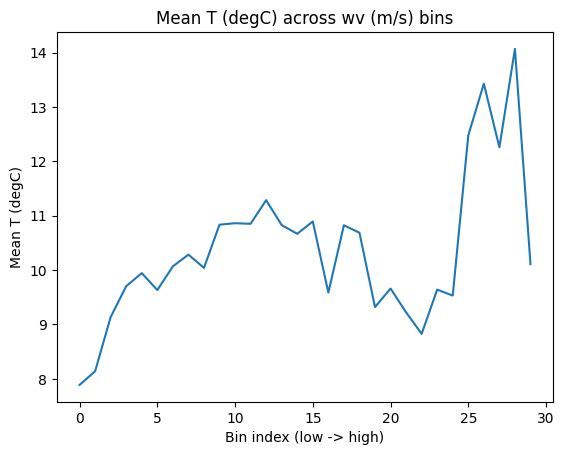

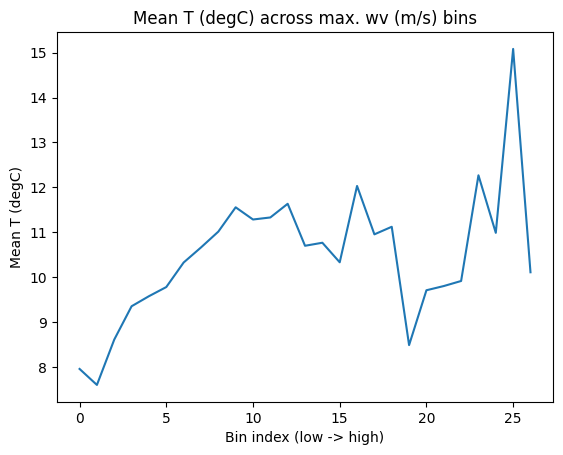

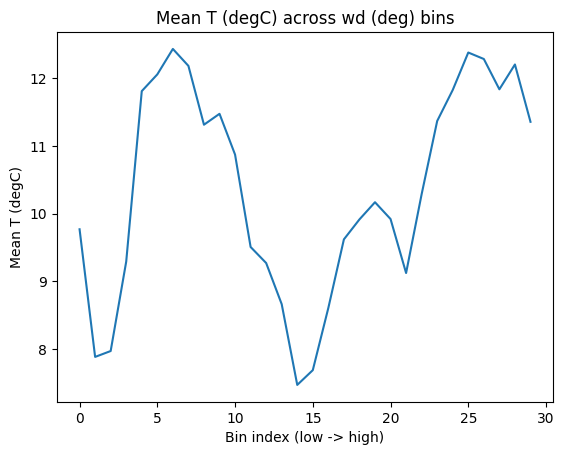

In [21]:
target = "T (degC)"
exclude = {target, "hour", "month"}
x_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

df_s = df.sample(50000, random_state=42)

for x in x_cols:
    # dividir x em 30 intervalos e ver média de T em cada intervalo
    bins = pd.cut(df_s[x], bins=30)
    m = df_s.groupby(bins)[target].mean()

    plt.figure()
    plt.plot(range(len(m)), m.values)
    plt.title(f"Mean {target} across {x} bins")
    plt.xlabel("Bin index (low -> high)")
    plt.ylabel(f"Mean {target}")
    plt.show()

### 3.5.11 Variables Mean by Hour

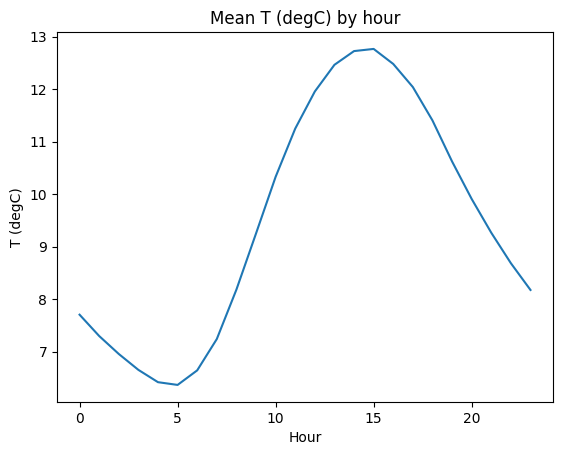

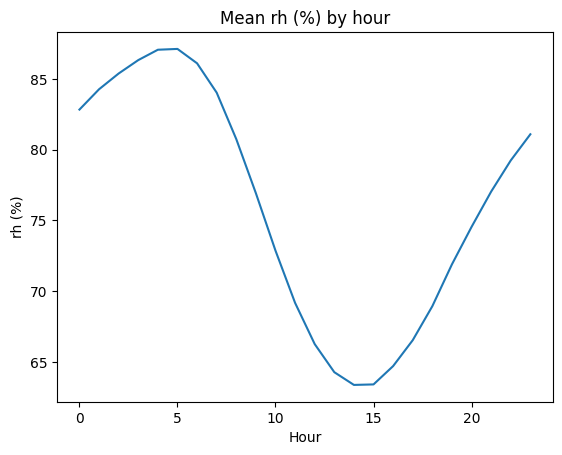

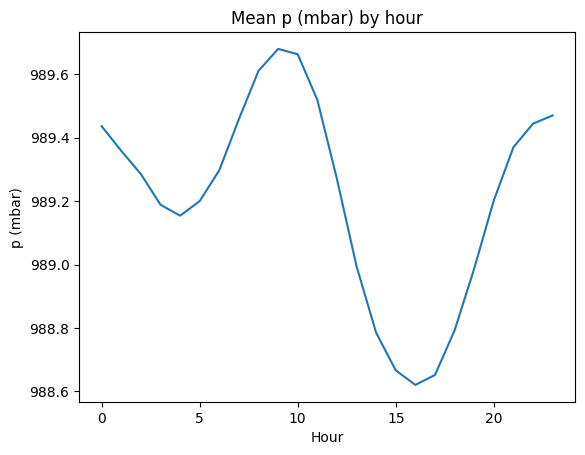

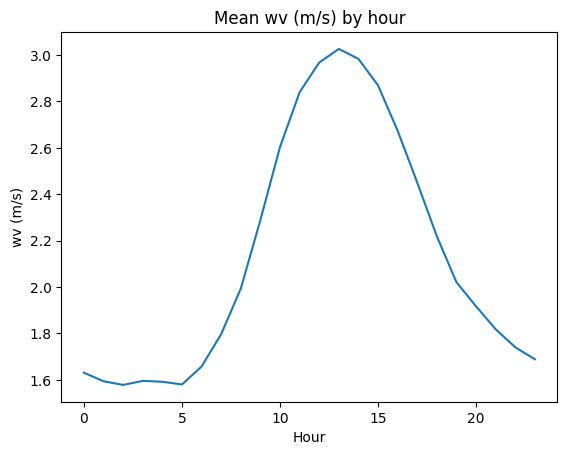

In [22]:
df["hour"] = df["Date Time"].dt.hour

vars_to_check = ["T (degC)", "rh (%)", "p (mbar)", "wv (m/s)"]
for v in vars_to_check:
    m = df.groupby("hour")[v].mean()
    plt.figure()
    plt.plot(m.index, m.values)
    plt.title(f"Mean {v} by hour")
    plt.xlabel("Hour")
    plt.ylabel(v)
    plt.show()

## 4. Data Understanding – Detailed Analysis

In [23]:
df = df.sort_values("Date Time").reset_index(drop=True)

target = "T (degC)"

### 4.1 Temporal Regularity and Gaps

In [24]:
# Check time deltas (frequency and gaps)
deltas = df["Date Time"].diff().dropna()
print("Most common deltas:")
display(deltas.value_counts().head(5))

mode_delta = deltas.value_counts().idxmax()
print("Mode delta:", mode_delta)

# Count gaps larger than the expected frequency
gaps = deltas[deltas > mode_delta]
print("Number of gaps larger than mode delta:", len(gaps))

# Show a few gaps (if any)
if len(gaps) > 0:
    idx = gaps.index[:10]
    display(df.loc[idx, ["Date Time"]].assign(delta=gaps.loc[idx].values))

Most common deltas:


Date Time
0 days 00:10:00    420218
0 days 00:00:00       327
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
Name: count, dtype: int64

Mode delta: 0 days 00:10:00
Number of gaps larger than mode delta: 5


,Date Time,delta
40378,2009-10-08 10:10:00,0 days 00:30:00
230019,2013-05-16 09:10:00,0 days 00:20:00
293556,2014-07-30 08:20:00,0 days 00:20:00
301673,2014-09-25 09:00:00,0 days 16:00:00
411267,2016-10-28 12:50:00,3 days 02:20:00


## 4.2 Seasonal Patterns
### 4.2.1 Stationarity (Basic Check)

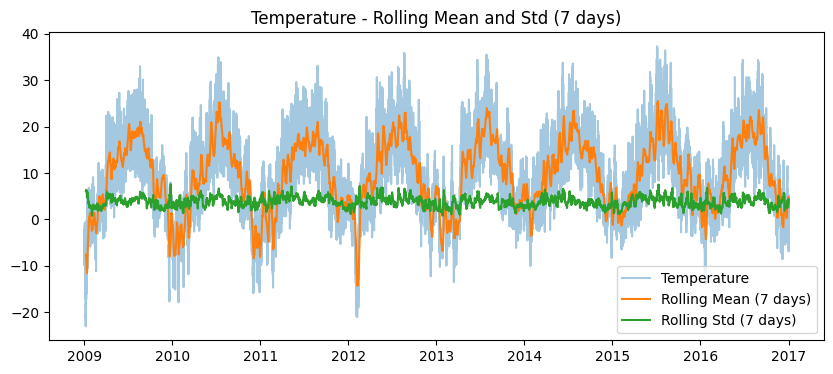

In [25]:
# Rolling mean and std for temperature (7-day window)
w = 7 * 24 * 6  # 7 days with 10-min data
t = df.set_index("Date Time")["T (degC)"]

roll_mean = t.rolling(w).mean()
roll_std = t.rolling(w).std()

plt.figure(figsize=(10, 4))
plt.plot(t, alpha=0.4, label="Temperature")
plt.plot(roll_mean, label="Rolling Mean (7 days)")
plt.plot(roll_std, label="Rolling Std (7 days)")
plt.title("Temperature - Rolling Mean and Std (7 days)")
plt.legend()
plt.show()

### 4.2.2 Preview of Hourly Resampling

In [26]:
feature_keys = [
    "p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)", "rh (%)",
    "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)",
    "H2OC (mmol/mol)", "rho (g/m**3)", "wv (m/s)", "max. wv (m/s)", "wd (deg)"
]

df_hourly = (
    df.set_index("Date Time")[feature_keys]
      .resample("1h")   # <- lowercase h
      .mean()
      .reset_index()
)

print("Hourly shape:", df_hourly.shape)
display(df_hourly.head())

Hourly shape: (70129, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


In [27]:
print("Hourly missing timestamps:", df_hourly["Date Time"].isna().sum())
print("NaNs per column (hourly):")
display(df_hourly.isna().sum())

Hourly missing timestamps: 0
NaNs per column (hourly):


Date Time           0
p (mbar)           88
T (degC)           88
Tpot (K)           88
Tdew (degC)        88
rh (%)             88
VPmax (mbar)       88
VPact (mbar)       88
VPdef (mbar)       88
sh (g/kg)          88
H2OC (mmol/mol)    88
rho (g/m**3)       88
wv (m/s)           90
max. wv (m/s)      91
wd (deg)           88
dtype: int64

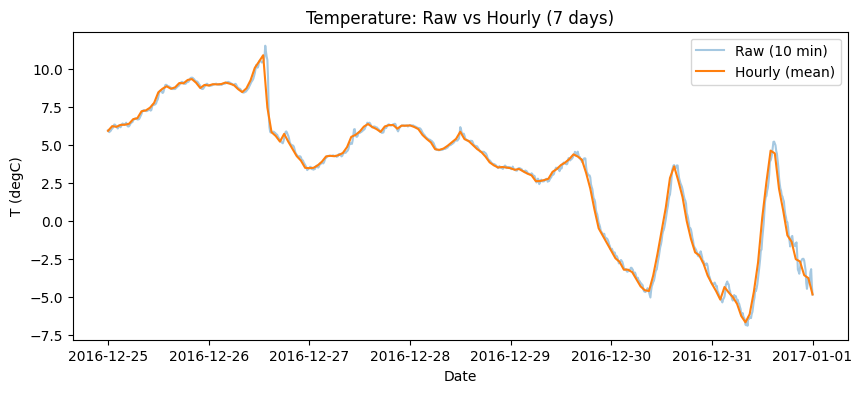

In [28]:
end = df["Date Time"].max()
start = end - pd.Timedelta(days=7)

raw_7d = df[(df["Date Time"] >= start) & (df["Date Time"] <= end)]
hourly_7d = df_hourly[(df_hourly["Date Time"] >= start) & (df_hourly["Date Time"] <= end)]

plt.figure(figsize=(10, 4))
plt.plot(raw_7d["Date Time"], raw_7d["T (degC)"], alpha=0.4, label="Raw (10 min)")
plt.plot(hourly_7d["Date Time"], hourly_7d["T (degC)"], label="Hourly (mean)")
plt.title("Temperature: Raw vs Hourly (7 days)")
plt.xlabel("Date")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

### 4.3 Find rows (hours) with NaNs

In [29]:
na_rows = df_hourly[df_hourly.isna().any(axis=1)].copy()
print("Hourly rows with NaN:", len(na_rows))
display(na_rows.head(10))
display(na_rows.tail(10))

Hourly rows with NaN: 91


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
50226,2014-09-24 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50227,2014-09-24 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50228,2014-09-24 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50229,2014-09-24 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50230,2014-09-24 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50231,2014-09-24 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50232,2014-09-25 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50233,2014-09-25 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50234,2014-09-25 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50235,2014-09-25 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
68570,2016-10-28 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68571,2016-10-28 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68572,2016-10-28 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68573,2016-10-28 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68574,2016-10-28 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68575,2016-10-28 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68576,2016-10-28 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68577,2016-10-28 09:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68578,2016-10-28 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68579,2016-10-28 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 4.3.1 Remove Nan 

In [30]:
# Clean hourly data by dropping hours with no observations
df_hourly_clean = df_hourly.dropna().reset_index(drop=True)

print("Hourly before cleaning:", df_hourly.shape)
print("Hourly after cleaning: ", df_hourly_clean.shape)

# Sanity check
print("Remaining NaNs:", df_hourly_clean.isna().sum().sum())

Hourly before cleaning: (70129, 15)
Hourly after cleaning:  (70038, 15)
Remaining NaNs: 0


## 5. Data Preparation

### 5.1 Dataset Scope and Columns

#### 5.1.1 Define target, inputs and frequency

In [31]:
# Target variable
target_col = "T (degC)"

# Input features (Jena standard set)
feature_keys = ["T (degC)", "p (mbar)", "rh (%)", "wv (m/s)", "max. wv (m/s)", "wd (deg)"]

# Final working dataframe (hourly, clean)
df_work = df_hourly_clean[["Date Time"] + feature_keys].copy()

print("df_work shape:", df_work.shape)
display(df_work.head())

df_work shape: (70038, 7)


,Date Time,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
1,2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2,2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
3,2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
4,2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


#### 5.1.2 Sanity checks (no NaNs, correct dtypes)

In [32]:
print("NaNs per column:")
display(df_work.isna().sum())

print("\nDtypes:")
display(df_work.dtypes)

NaNs per column:


Date Time        0
T (degC)         0
p (mbar)         0
rh (%)           0
wv (m/s)         0
max. wv (m/s)    0
wd (deg)         0
dtype: int64


Dtypes:


Date Time        datetime64[us]
T (degC)                float64
p (mbar)                float64
rh (%)                  float64
wv (m/s)                float64
max. wv (m/s)           float64
wd (deg)                float64
dtype: object

#### 5.1.3 Confirm frequency is hourly

In [33]:
# Check time delta between consecutive rows
deltas = df_work["Date Time"].diff().dropna()
print("Most common deltas:")
display(deltas.value_counts().head(3))

Most common deltas:


Date Time
0 days 01:00:00    70034
0 days 16:00:00        1
0 days 04:00:00        1
Name: count, dtype: int64

#### 5.1.4 Set Date Time as index

In [34]:
df_work = df_work.set_index("Date Time")
print("Index type:", type(df_work.index))
display(df_work.head())

Index type: <class 'pandas.DatetimeIndex'>


,T (degC),p (mbar),rh (%),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,
2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333


### 5.2 Temporal Split (Train / Validation / Test)

#### 5.2.1 Split Proportions

In [35]:
# Split ratios
train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

n_total = len(df_work)
n_train = int(n_total * train_ratio)
n_val   = int(n_total * val_ratio)

print("Total samples:", n_total)
print("Train size:", n_train)
print("Val size:", n_val)
print("Test size:", n_total - n_train - n_val)

Total samples: 70038
Train size: 49026
Val size: 10505
Test size: 10507


In [36]:
#### 4.2.2 Criar os conjuntos (contíguos no tempo)

In [37]:
df_train = df_work.iloc[:n_train]
df_val   = df_work.iloc[n_train:n_train + n_val]
df_test  = df_work.iloc[n_train + n_val:]

print("Train period:", df_train.index.min(), "->", df_train.index.max())
print("Val period:  ", df_val.index.min(),   "->", df_val.index.max())
print("Test period: ", df_test.index.min(),  "->", df_test.index.max())

print("\nShapes:")
print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train period: 2009-01-01 00:00:00 -> 2014-08-05 17:00:00
Val period:   2014-08-05 18:00:00 -> 2015-10-18 04:00:00
Test period:  2015-10-18 05:00:00 -> 2017-01-01 00:00:00

Shapes:
Train: (49026, 6)
Val:   (10505, 6)
Test:  (10507, 6)


#### 4.2.3 Visual target over splits

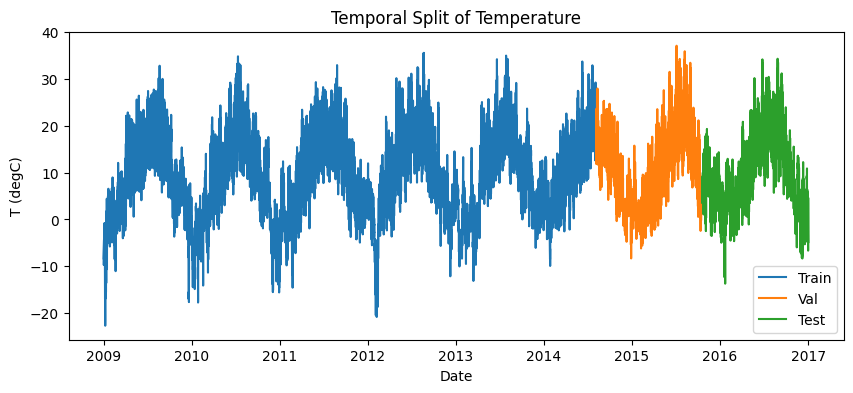

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(df_train.index, df_train[target_col], label="Train")
plt.plot(df_val.index,   df_val[target_col],   label="Val")
plt.plot(df_test.index,  df_test[target_col],  label="Test")
plt.title("Temporal Split of Temperature")
plt.xlabel("Date")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

### 5.3 Feature Engineering

In [39]:
def add_time_features(df_in):
    df = df_in.copy()
    # time parts
    hour = df.index.hour
    doy  = df.index.dayofyear

    # cyclical encoding
    df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    df["doy_sin"]  = np.sin(2 * np.pi * doy / 365.25)
    df["doy_cos"]  = np.cos(2 * np.pi * doy / 365.25)

    # wind direction is circular
    wd = df["wd (deg)"].astype(float)
    df["wd_sin"] = np.sin(2 * np.pi * wd / 360.0)
    df["wd_cos"] = np.cos(2 * np.pi * wd / 360.0)

    return df

df_train_fe = add_time_features(df_train)
df_val_fe   = add_time_features(df_val)
df_test_fe  = add_time_features(df_test)

print(df_train_fe.shape, df_val_fe.shape, df_test_fe.shape)

(49026, 12) (10505, 12) (10507, 12)


## 5.4 Scaling

In [40]:
from sklearn.preprocessing import StandardScaler

# Choose features to scale (all columns)
feat_cols = df_train_fe.columns.tolist()

scaler = StandardScaler()
scaler.fit(df_train_fe[feat_cols])

train_scaled = scaler.transform(df_train_fe[feat_cols])
val_scaled   = scaler.transform(df_val_fe[feat_cols])
test_scaled  = scaler.transform(df_test_fe[feat_cols])

# Back to DataFrame (keep index)
df_train_s = pd.DataFrame(train_scaled, index=df_train_fe.index, columns=feat_cols)
df_val_s   = pd.DataFrame(val_scaled,   index=df_val_fe.index,   columns=feat_cols)
df_test_s  = pd.DataFrame(test_scaled,  index=df_test_fe.index,  columns=feat_cols)

print("NaNs after scaling:", df_train_s.isna().sum().sum(), df_val_s.isna().sum().sum(), df_test_s.isna().sum().sum())

NaNs after scaling: 0 0 0


## 5.5 Windowing (L=120, H=24)

In [41]:
from numpy.lib.stride_tricks import sliding_window_view

L = 120  # input window (hours)
H = 24   # forecast horizon (hours)

def make_windows(df_scaled, target_name, L, H):
    # Cast to float32 once here — avoids repeated float64→float32
    # conversion inside TensorFlow on every batch during training.
    data = df_scaled.values.astype(np.float32)
    target_idx = df_scaled.columns.get_loc(target_name)
    n_samples = len(data) - L - H

    # Build X windows fully vectorized using stride tricks — no Python loop.
    # sliding_window_view(data, L, axis=0) → (n-L+1, n_features, L)
    # transpose(0,2,1)                     → (n-L+1, L, n_features)
    # [:n_samples]                          → (n_samples, L, n_features)
    X = sliding_window_view(data, window_shape=L, axis=0).transpose(0, 2, 1)[:n_samples].copy()

    # Build y windows: target column only, H steps ahead of each X window.
    # sliding_window_view on target[L:] → (n-L-H+1, H), take [:n_samples]
    y = sliding_window_view(data[L:, target_idx], window_shape=H)[:n_samples].copy()

    return X, y

X_train, y_train = make_windows(df_train_s, target_col, L, H)
X_val,   y_val   = make_windows(df_val_s,   target_col, L, H)
X_test,  y_test  = make_windows(df_test_s,  target_col, L, H)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)
print("dtype:", X_train.dtype)

X_train: (48882, 120, 12) y_train: (48882, 24)
X_val:   (10361, 120, 12) y_val:   (10361, 24)
X_test:  (10363, 120, 12) y_test:  (10363, 24)
dtype: float32


#### 5.5.1 Baseline: Persistence

In [42]:
# persistence: predict next 24 hours as last observed temperature in the input window
target_idx = df_test_s.columns.get_loc(target_col)

last_T = X_test[:, -1, target_idx]  # last temp in each window
y_pred_persist = np.repeat(last_T[:, None], y_test.shape[1], axis=1)

print(y_pred_persist.shape)

(10363, 24)


#### 5.5.2 Metrics

In [43]:
def eval_multihorizon(y_true, y_pred):
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(mean_squared_error(y_true.reshape(-1), y_pred.reshape(-1)))
    return mae, rmse

mae_p, rmse_p = eval_multihorizon(y_test, y_pred_persist)
print("Persistence - MAE:", mae_p, "RMSE:", rmse_p)

Persistence - MAE: 0.36366111040115356 RMSE: 0.49212988258867824


#### 5.5.3 MAE by horizont

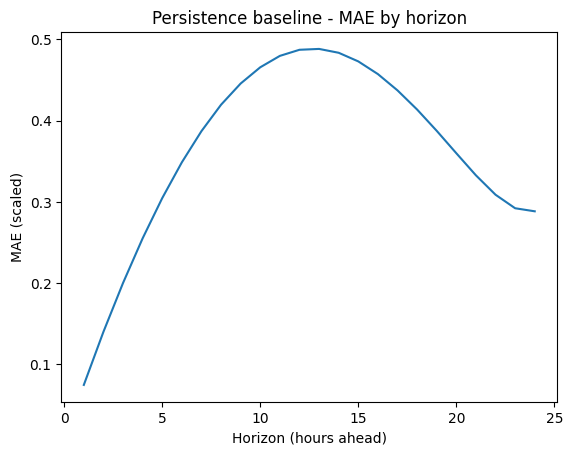

In [44]:
mae_by_h = np.mean(np.abs(y_test - y_pred_persist), axis=0)

plt.figure()
plt.plot(range(1, len(mae_by_h) + 1), mae_by_h)
plt.title("Persistence baseline - MAE by horizon")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("MAE (scaled)")
plt.show()

# 6. Model: Transformer v3 (PatchTST — pruner fix + focused search)

**Changes from v2:**
1. **Pruner fix**: `min_resource=6` ensures every trial survives past the 5-epoch warmup before pruning kicks in
2. **Softer pruning**: `reduction_factor=2` keeps top 50% per bracket instead of 33%
3. **Focused search space**: locked in patterns that won in both v1 and v2 (`huber1`, `adamw`, `noise=0.05`)
4. **max_epochs=60**: gives the cosine schedule more room to converge


In [45]:
print("TF version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs found:", gpus)

if gpus:
    # Avoid TF grabbing all GPU memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU is available and memory growth is enabled.")
else:
    print("No GPU found. Training will run on CPU.")

TF version: 2.20.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available and memory growth is enabled.


### 6.1 Setup: reproducibility

In [46]:
tf.random.set_seed(42)
np.random.seed(42)

H = y_train.shape[1]
L = X_train.shape[1]
n_features = X_train.shape[2]

### 6.2 Build function: PatchTST-style Transformer

In [47]:
class WarmupCosineSchedule(keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup for `warmup_steps`, then cosine decay to `min_lr`."""

    def __init__(self, base_lr, warmup_steps, total_steps, min_lr=1e-6):
        super().__init__()
        self.base_lr = base_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.min_lr = min_lr

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = self.base_lr * (step / tf.maximum(tf.cast(self.warmup_steps, tf.float32), 1.0))
        cos_decay = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (
            1.0 + tf.math.cos(
                np.pi * (step - self.warmup_steps)
                / tf.maximum(tf.cast(self.total_steps - self.warmup_steps, tf.float32), 1.0)
            )
        )
        return tf.where(step < self.warmup_steps, warmup, cos_decay)

    def get_config(self):
        return {
            "base_lr": self.base_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "min_lr": self.min_lr,
        }


def positional_encoding_sinusoidal(length, d_model):
    """Fixed sinusoidal positional encoding."""
    pos = tf.cast(tf.range(length)[:, tf.newaxis], tf.float32)
    dim = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
    angles = pos / tf.pow(10000.0, (2.0 * (dim // 2)) / tf.cast(d_model, tf.float32))
    sin_part = tf.math.sin(angles[:, 0::2])
    cos_part = tf.math.cos(angles[:, 1::2])
    return tf.cast(tf.concat([sin_part, cos_part], axis=-1)[:, :d_model], tf.float32)


def build_transformer_model(
    L, n_features, H,
    d_model=64,
    n_heads=4,
    n_blocks=2,
    ff_dim=128,
    patch_size=8,
    dropout=0.1,
    dense_units=0,
    dense_activation="relu",
    learning_rate=1e-3,
    clipnorm=1.0,
    optimizer_name="adam",
    weight_decay=1e-5,
    loss_name="mse",
    gaussian_noise_std=0.0,
    warmup_epochs=5,
    max_epochs=40,
    steps_per_epoch=1,
):
    """
    PatchTST-style Transformer for multi-step time series forecasting.

    Key differences from v1:
      - Patch embedding: groups P consecutive timesteps → one token
        (L=120, P=8 → 15 tokens; reduces noise, strengthens attention)
      - Pre-LayerNorm: LN before attention/FFN (more stable gradients)
      - Last-token output: uses final patch repr instead of global avg pool
      - Warmup + cosine LR schedule built into the optimizer
    """
    d_model = (d_model // n_heads) * n_heads
    if d_model == 0:
        d_model = n_heads

    # Number of patches (truncate if L not divisible by patch_size)
    n_patches = L // patch_size
    effective_L = n_patches * patch_size  # may discard a few trailing timesteps

    inputs = keras.Input(shape=(L, n_features))   # (batch, L, n_features)
    x = inputs

    # Optional input noise
    if gaussian_noise_std and gaussian_noise_std > 0:
        x = layers.GaussianNoise(gaussian_noise_std)(x)

    # ── Patch embedding ────────────────────────────────────────────────────
    # Truncate to effective_L, then reshape to (batch, n_patches, patch_size * n_features)
    x = x[:, :effective_L, :]
    x = layers.Reshape((n_patches, patch_size * n_features))(x)

    # Project each patch to d_model
    x = layers.Dense(d_model)(x)                # (batch, n_patches, d_model)

    # Add sinusoidal positional encoding over patch positions
    pe = positional_encoding_sinusoidal(n_patches, d_model)
    x = x + pe[tf.newaxis, :, :]

    x = layers.Dropout(dropout)(x)

    # ── Transformer encoder blocks (Pre-LayerNorm) ─────────────────────────
    for _ in range(n_blocks):
        # Pre-LN Multi-Head Self-Attention
        x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
        attn_out = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads,
            dropout=dropout,
        )(x_norm, x_norm)
        x = x + attn_out                       # residual

        # Pre-LN Feed-Forward Network
        x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
        ff = layers.Dense(ff_dim, activation="relu")(x_norm)
        ff = layers.Dropout(dropout)(ff)
        ff = layers.Dense(d_model)(ff)
        x = x + ff                              # residual

    # Final LayerNorm (standard for pre-LN architectures)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # ── Last-token output (instead of GlobalAveragePooling) ────────────────
    x = x[:, -1, :]                             # (batch, d_model)

    # Optional dense head
    if dense_units and dense_units > 0:
        if dense_activation == "leaky_relu":
            x = layers.Dense(dense_units)(x)
            x = layers.LeakyReLU(negative_slope=0.1)(x)
        else:
            x = layers.Dense(dense_units, activation=dense_activation)(x)
        x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(H)(x)                # (batch, H)
    model = keras.Model(inputs, outputs)

    # ── LR schedule: linear warmup + cosine decay ──────────────────────────
    total_steps = max_epochs * steps_per_epoch
    warmup_steps = warmup_epochs * steps_per_epoch
    lr_schedule = WarmupCosineSchedule(
        base_lr=learning_rate,
        warmup_steps=warmup_steps,
        total_steps=total_steps,
        min_lr=1e-6,
    )

    # Optimizer
    if optimizer_name.lower() == "adamw":
        opt = keras.optimizers.AdamW(
            learning_rate=lr_schedule,
            weight_decay=weight_decay,
            clipnorm=clipnorm,
        )
    else:
        opt = keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=clipnorm)

    # Loss
    if loss_name == "mae":
        loss = "mae"
    elif loss_name == "huber1":
        loss = keras.losses.Huber(delta=1.0)
    elif loss_name == "huber2":
        loss = keras.losses.Huber(delta=2.0)
    else:
        loss = "mse"

    model.compile(optimizer=opt, loss=loss, metrics=["mae"])
    return model


### 6.3 Training wrapper + callbacks

In [48]:
def train_one_config(cfg, X_train, y_train, X_val, y_val, max_epochs=60, fit_verbose=0):
    # Compute steps_per_epoch for the LR schedule
    steps_per_epoch = int(np.ceil(len(X_train) / cfg["batch_size"]))

    model = build_transformer_model(
        L=L, n_features=n_features, H=H,
        d_model=cfg["d_model"],
        n_heads=cfg["n_heads"],
        n_blocks=cfg["n_blocks"],
        ff_dim=cfg["ff_dim"],
        patch_size=cfg["patch_size"],
        dropout=cfg["dropout"],
        dense_units=cfg["dense_units"],
        dense_activation=cfg["dense_activation"],
        learning_rate=cfg["lr"],
        clipnorm=cfg["clipnorm"],
        optimizer_name=cfg["optimizer"],
        weight_decay=cfg.get("weight_decay", 0.0),
        loss_name=cfg.get("loss_name", "mse"),
        gaussian_noise_std=cfg.get("gaussian_noise_std", 0.0),
        warmup_epochs=5,
        max_epochs=max_epochs,
        steps_per_epoch=steps_per_epoch,
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ]
    # Note: we do NOT use ReduceLROnPlateau because the warmup+cosine schedule
    # already handles LR decay. Using both would cause conflicts.

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=cfg["batch_size"],
        verbose=fit_verbose,
        callbacks=callbacks,
    )

    best_val_loss = float(np.min(history.history["val_loss"]))
    best_val_mae  = float(np.min(history.history["val_mae"]))
    return model, history, best_val_loss, best_val_mae


### 6.4 Optuna Hyperparameter Search

In [49]:
class OptunaPruningCallback(keras.callbacks.Callback):
    """Reports val_loss to Optuna each epoch; prunes unpromising trials."""
    def __init__(self, trial):
        super().__init__()
        self.trial = trial

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get("val_loss")
        if val_loss is None:
            return
        self.trial.report(val_loss, epoch)
        if self.trial.should_prune():
            raise optuna.exceptions.TrialPruned()


best_holder = {"val_loss": np.inf, "model": None, "cfg": None, "history": None}


def objective(trial):
    # ── Focused search space based on v1 + v2 findings ───────────────────
    # Locked: adamw, huber1, noise=0.05 (won in both v1 and v2)
    n_heads     = trial.suggest_categorical("n_heads",     [2, 4, 8])
    d_model     = trial.suggest_categorical("d_model",     [64, 128, 256])
    n_blocks    = trial.suggest_int("n_blocks", 1, 4)
    ff_dim      = trial.suggest_categorical("ff_dim",      [128, 256, 512])
    patch_size  = trial.suggest_categorical("patch_size",  [4, 6, 8, 12])
    dropout     = trial.suggest_categorical("dropout",     [0.0, 0.1, 0.2, 0.3])
    dense_units = trial.suggest_categorical("dense_units", [0, 64, 128])
    dense_act   = trial.suggest_categorical("dense_activation", ["relu", "gelu"])
    lr          = trial.suggest_categorical("lr",          [2e-3, 1e-3, 5e-4, 3e-4, 1e-4])
    batch_size  = trial.suggest_categorical("batch_size",  [128, 256, 512])
    clipnorm    = trial.suggest_categorical("clipnorm",    [1.0, 2.0, 5.0])
    weight_decay= trial.suggest_categorical("weight_decay",[0.0, 1e-5, 1e-4])

    # Fixed based on v1+v2 results
    opt_name   = "adamw"
    loss_name  = "huber1"
    noise_std  = 0.05

    # d_model must be divisible by n_heads
    d_model = (d_model // n_heads) * n_heads
    if d_model == 0:
        d_model = n_heads

    # patch_size must divide L evenly
    if L % patch_size != 0:
        candidates = [p for p in [4, 6, 8, 12] if L % p == 0]
        patch_size = min(candidates, key=lambda p: abs(p - patch_size))

    max_epochs = 60
    steps_per_epoch = int(np.ceil(len(X_train) / batch_size))

    cfg = dict(
        d_model=d_model, n_heads=n_heads, n_blocks=n_blocks, ff_dim=ff_dim,
        patch_size=patch_size, dropout=dropout, dense_units=dense_units,
        dense_activation=dense_act, lr=lr, batch_size=batch_size,
        clipnorm=clipnorm, optimizer=opt_name, weight_decay=weight_decay,
        loss_name=loss_name, gaussian_noise_std=noise_std,
    )

    model = build_transformer_model(
        L=L, n_features=n_features, H=H,
        d_model=d_model, n_heads=n_heads, n_blocks=n_blocks, ff_dim=ff_dim,
        patch_size=patch_size, dropout=dropout, dense_units=dense_units,
        dense_activation=dense_act, learning_rate=lr, clipnorm=clipnorm,
        optimizer_name=opt_name, weight_decay=weight_decay, loss_name=loss_name,
        gaussian_noise_std=noise_std, warmup_epochs=5, max_epochs=max_epochs,
        steps_per_epoch=steps_per_epoch,
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        OptunaPruningCallback(trial),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks,
    )

    best_val_loss = float(np.min(history.history["val_loss"]))
    best_val_mae  = float(np.min(history.history["val_mae"]))

    if best_val_loss < best_holder["val_loss"]:
        best_holder["val_loss"]  = best_val_loss
        best_holder["model"]     = model
        best_holder["cfg"]       = cfg
        best_holder["history"]   = history

    trial.set_user_attr("val_mae", best_val_mae)
    return best_val_loss


### 6.5 Run Optuna Search

[60/60] Trial #59 → PRUNED
  Complete: 32 | Pruned: 28 | Best so far: 0.0352


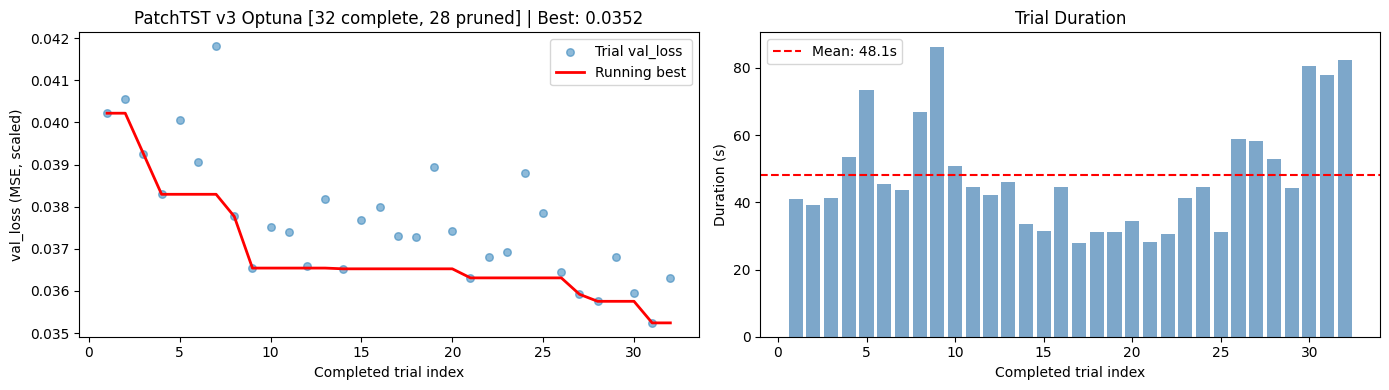


Optimization complete!
Best trial #56 — val_loss: 0.0352
Best params: {'n_heads': 2, 'd_model': 64, 'n_blocks': 1, 'ff_dim': 512, 'patch_size': 8, 'dropout': 0.3, 'dense_units': 0, 'dense_activation': 'relu', 'lr': 0.002, 'batch_size': 128, 'clipnorm': 1.0, 'weight_decay': 1e-05}


In [50]:
from IPython.display import clear_output

def progress_callback(study, trial):
    """Live chart redrawn after every trial (complete or pruned)."""
    clear_output(wait=True)
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    n_done    = len(study.trials)

    state_str = ("PRUNED" if trial.state == optuna.trial.TrialState.PRUNED
                 else f"val_loss={trial.value:.4f}")
    print(f"[{n_done}/60] Trial #{trial.number} → {state_str}")
    if completed:
        print(f"  Complete: {len(completed)} | Pruned: {len(pruned)} | Best so far: {study.best_value:.4f}")

    if len(completed) < 2:
        return

    losses       = [t.value for t in completed]
    running_best = pd.Series(losses).cummin()
    durations    = [t.duration.total_seconds() for t in completed if t.duration]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax = axes[0]
    ax.scatter(range(1, len(losses) + 1), losses, alpha=0.5, s=30, label="Trial val_loss")
    ax.plot(range(1, len(losses) + 1), running_best, color="red", linewidth=2, label="Running best")
    ax.set_title(
        f"PatchTST v3 Optuna [{len(completed)} complete, {len(pruned)} pruned]"
        f" | Best: {study.best_value:.4f}"
    )
    ax.set_xlabel("Completed trial index")
    ax.set_ylabel("val_loss (MSE, scaled)")
    ax.legend()

    ax = axes[1]
    ax.bar(range(1, len(durations) + 1), durations, color="steelblue", alpha=0.7)
    if durations:
        ax.axhline(np.mean(durations), color="red", linestyle="--",
                   label=f"Mean: {np.mean(durations):.1f}s")
    ax.set_title("Trial Duration")
    ax.set_xlabel("Completed trial index")
    ax.set_ylabel("Duration (s)")
    ax.legend()

    plt.tight_layout()
    plt.show()


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.HyperbandPruner(min_resource=6, max_resource=60, reduction_factor=2),
)

study.optimize(objective, n_trials=60, callbacks=[progress_callback])

print("\nOptimization complete!")
print(f"Best trial #{study.best_trial.number} — val_loss: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


In [51]:
rows = []
for t in study.trials:
    if t.state != optuna.trial.TrialState.COMPLETE:
        continue
    row = {
        "name":           f"trial_{t.number:02d}",
        "best_val_loss":  t.value,
        "best_val_mae":   t.user_attrs.get("val_mae", np.nan),
        "train_time_sec": round(t.duration.total_seconds(), 1) if t.duration else np.nan,
        **t.params,
    }
    rows.append(row)

n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
results_df = pd.DataFrame(rows).sort_values("best_val_loss").reset_index(drop=True)

print(f"Completed trials: {len(rows)} | Pruned: {n_pruned}")
display(results_df.head(10))

best_cfg_named = {**best_holder["cfg"], "name": f"trial_{study.best_trial.number:02d}"}
best = {
    "val_loss": best_holder["val_loss"],
    "model":    best_holder["model"],
    "history":  best_holder["history"],
    "cfg":      best_cfg_named,
}
best_transformer = best_holder["model"]


Completed trials: 32 | Pruned: 28


,name,best_val_loss,best_val_mae,train_time_sec,n_heads,d_model,n_blocks,ff_dim,patch_size,dropout,dense_units,dense_activation,lr,batch_size,clipnorm,weight_decay
0,trial_56,0.035243,0.198983,78.1,2,64,1,512,8,0.3,0,relu,0.0020,128,1.0,0.00001
1,trial_53,0.035755,0.200524,53.0,2,64,1,512,8,0.2,0,relu,0.0020,128,1.0,0.00001
2,trial_52,0.035922,0.200278,58.3,2,64,1,512,8,0.2,0,relu,0.0020,128,1.0,0.00001
3,trial_55,0.035961,0.201038,80.6,2,64,1,512,8,0.3,0,relu,0.0005,128,1.0,0.00001
4,trial_43,0.036311,0.202323,28.3,2,64,1,512,8,0.2,0,gelu,0.0020,256,1.0,0.00001
5,trial_57,0.036313,0.200771,82.3,8,64,1,512,8,0.3,0,relu,0.0005,128,1.0,0.00001
6,trial_51,0.036443,0.200906,58.7,2,64,1,512,8,0.2,0,relu,0.0020,128,1.0,0.00001
7,trial_22,0.036526,0.202609,33.4,2,64,1,512,8,0.2,0,gelu,0.0020,256,1.0,0.00001
8,trial_09,0.036544,0.202881,86.3,2,64,1,128,12,0.2,0,gelu,0.0005,128,5.0,0.00000
9,trial_15,0.036596,0.203585,42.1,2,64,1,128,12,0.2,64,gelu,0.0020,256,5.0,0.00000


### 6.6 Plot training curves (best PatchTST)

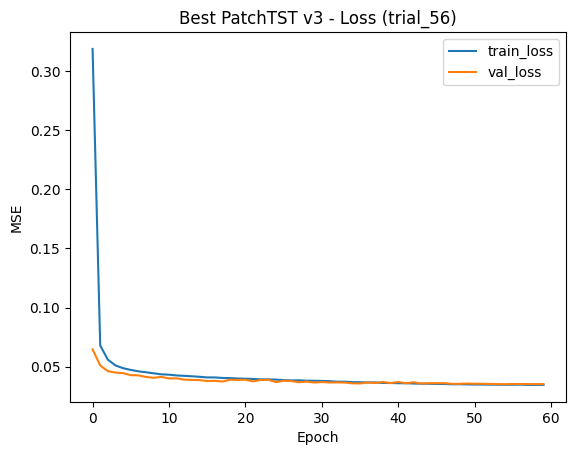

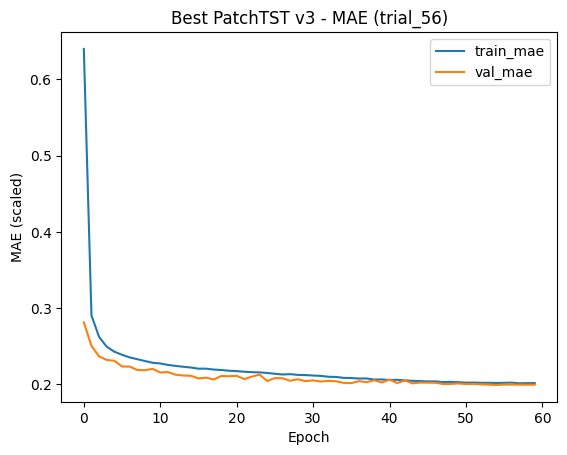

In [52]:
hist = best["history"].history

plt.figure()
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title(f"Best PatchTST v3 - Loss ({best['cfg']['name']})")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist["mae"], label="train_mae")
plt.plot(hist["val_mae"], label="val_mae")
plt.title(f"Best PatchTST v3 - MAE ({best['cfg']['name']})")
plt.xlabel("Epoch")
plt.ylabel("MAE (scaled)")
plt.legend()
plt.show()


### 6.7 Evaluate best PatchTST on TEST (scaled)

In [53]:
y_pred_transformer_scaled = best_transformer.predict(X_test, verbose=0)

yt = y_test.reshape(-1)
yp = y_pred_transformer_scaled.reshape(-1)

mae  = mean_absolute_error(yt, yp)
rmse = np.sqrt(mean_squared_error(yt, yp))
r2   = r2_score(yt, yp)

print("TEST (scaled) - MAE:", mae, "RMSE:", rmse, "R2:", r2)


TEST (scaled) - MAE: 0.1964094042778015 RMSE: 0.2583351617153643 R2: 0.9182993769645691


### 6.8 Convert predictions to °C + compute MAE/RMSE/MAPE/R²

In [54]:
def inverse_scale_target(y_scaled, scaler, feature_names, target_col):
    t_idx = feature_names.index(target_col)
    mean = scaler.mean_[t_idx]
    std  = scaler.scale_[t_idx]
    return y_scaled * std + mean

y_test_c = inverse_scale_target(y_test, scaler, feat_cols, target_col)
y_pred_c = inverse_scale_target(y_pred_transformer_scaled, scaler, feat_cols, target_col)


#### 6.8.1 Metrics in °C (global + MAPE)

In [55]:
eps = 1e-6
yt = y_test_c.reshape(-1)
yp = y_pred_c.reshape(-1)

mae_c = mean_absolute_error(yt, yp)
rmse_c = np.sqrt(mean_squared_error(yt, yp))
r2_c = r2_score(yt, yp)

print("TEST (°C) - MAE:", mae_c, "RMSE:", rmse_c, "R2:", r2_c)

TEST (°C) - MAE: 1.697869314899899 RMSE: 2.233189021634906 R2: 0.9182994056048976


### 6.9 MAE by horizon (°C)

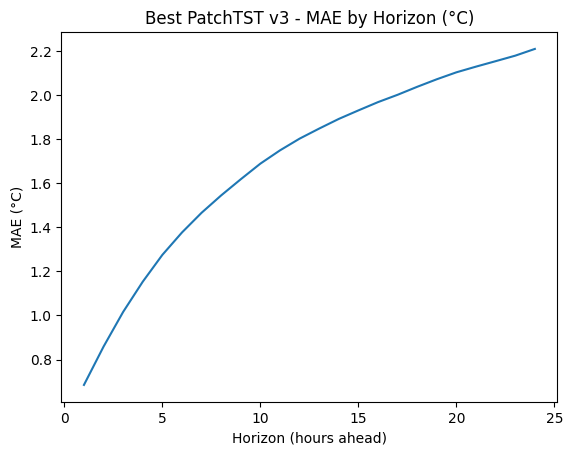

In [56]:
H = y_test.shape[1]
mae_by_h = np.mean(np.abs(y_test_c - y_pred_c), axis=0)

plt.figure()
plt.plot(range(1, H+1), mae_by_h)
plt.title("Best PatchTST v3 - MAE by Horizon (°C)")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("MAE (°C)")
plt.show()


In [57]:
results_df.to_csv("transformer_v3_optuna_results.csv", index=False)

### 7. Overview table + top/bottom configs

In [58]:
display(results_df.head(10))     # top 10
display(results_df.tail(10))     # worst 10
print("Configs tested:", len(results_df))
print("Best val_loss:", results_df["best_val_loss"].min())
print("Best val_mae:", results_df["best_val_mae"].min())

,name,best_val_loss,best_val_mae,train_time_sec,n_heads,d_model,n_blocks,ff_dim,patch_size,dropout,dense_units,dense_activation,lr,batch_size,clipnorm,weight_decay
0,trial_56,0.035243,0.198983,78.1,2,64,1,512,8,0.3,0,relu,0.0020,128,1.0,0.00001
1,trial_53,0.035755,0.200524,53.0,2,64,1,512,8,0.2,0,relu,0.0020,128,1.0,0.00001
2,trial_52,0.035922,0.200278,58.3,2,64,1,512,8,0.2,0,relu,0.0020,128,1.0,0.00001
3,trial_55,0.035961,0.201038,80.6,2,64,1,512,8,0.3,0,relu,0.0005,128,1.0,0.00001
4,trial_43,0.036311,0.202323,28.3,2,64,1,512,8,0.2,0,gelu,0.0020,256,1.0,0.00001
5,trial_57,0.036313,0.200771,82.3,8,64,1,512,8,0.3,0,relu,0.0005,128,1.0,0.00001
6,trial_51,0.036443,0.200906,58.7,2,64,1,512,8,0.2,0,relu,0.0020,128,1.0,0.00001
7,trial_22,0.036526,0.202609,33.4,2,64,1,512,8,0.2,0,gelu,0.0020,256,1.0,0.00001
8,trial_09,0.036544,0.202881,86.3,2,64,1,128,12,0.2,0,gelu,0.0005,128,5.0,0.00000
9,trial_15,0.036596,0.203585,42.1,2,64,1,128,12,0.2,64,gelu,0.0020,256,5.0,0.00000


,name,best_val_loss,best_val_mae,train_time_sec,n_heads,d_model,n_blocks,ff_dim,patch_size,dropout,dense_units,dense_activation,lr,batch_size,clipnorm,weight_decay
22,trial_21,0.038180,0.208609,46.1,2,256,2,512,6,0.2,0,gelu,0.0020,256,1.0,0.00001
23,trial_03,0.038296,0.209172,53.4,4,128,1,128,4,0.2,0,gelu,0.0020,128,1.0,0.00001
24,trial_48,0.038800,0.210864,44.5,2,64,4,512,12,0.2,64,relu,0.0020,512,1.0,0.00001
25,trial_36,0.038942,0.209356,31.2,8,128,1,128,8,0.0,0,gelu,0.0003,256,2.0,0.00001
26,trial_05,0.039061,0.212210,45.6,4,64,4,128,8,0.0,0,gelu,0.0003,256,2.0,0.00000
27,trial_02,0.039259,0.213843,41.2,8,128,4,128,8,0.0,128,gelu,0.0001,512,5.0,0.00010
28,trial_04,0.040061,0.215011,73.4,8,256,4,512,6,0.3,0,gelu,0.0003,512,2.0,0.00000
29,trial_00,0.040220,0.216486,41.0,4,64,1,128,6,0.3,128,gelu,0.0005,512,5.0,0.00000
30,trial_01,0.040548,0.215034,39.1,4,128,4,256,12,0.1,0,gelu,0.0005,512,2.0,0.00010
31,trial_06,0.041812,0.220624,43.7,4,128,4,256,12,0.2,64,relu,0.0005,512,5.0,0.00000


Configs tested: 32
Best val_loss: 0.03524294123053551
Best val_mae: 0.19898328185081482


#### 7.1 Histogram: distribution of validation performance

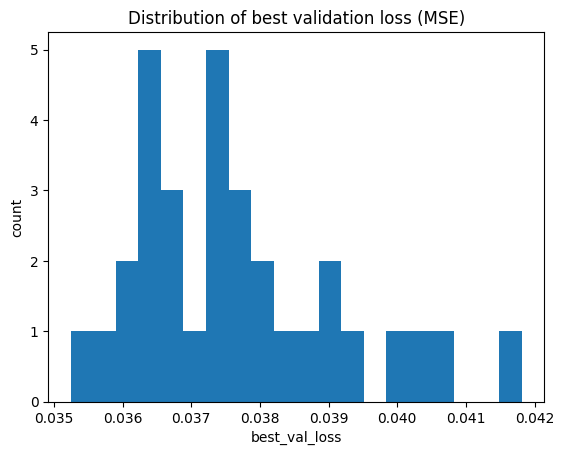

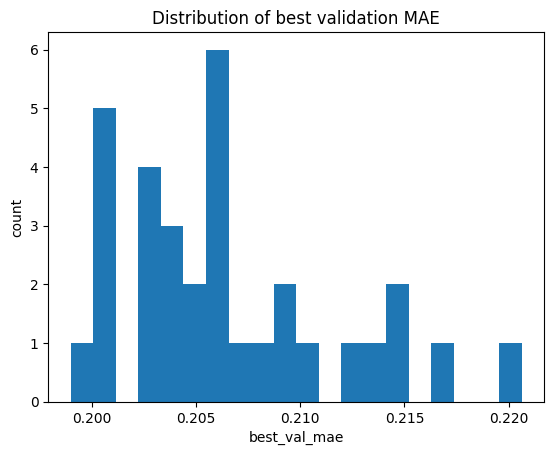

In [59]:
plt.figure()
plt.hist(results_df["best_val_loss"], bins=20)
plt.title("Distribution of best validation loss (MSE)")
plt.xlabel("best_val_loss")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(results_df["best_val_mae"], bins=20)
plt.title("Distribution of best validation MAE")
plt.xlabel("best_val_mae")
plt.ylabel("count")
plt.show()

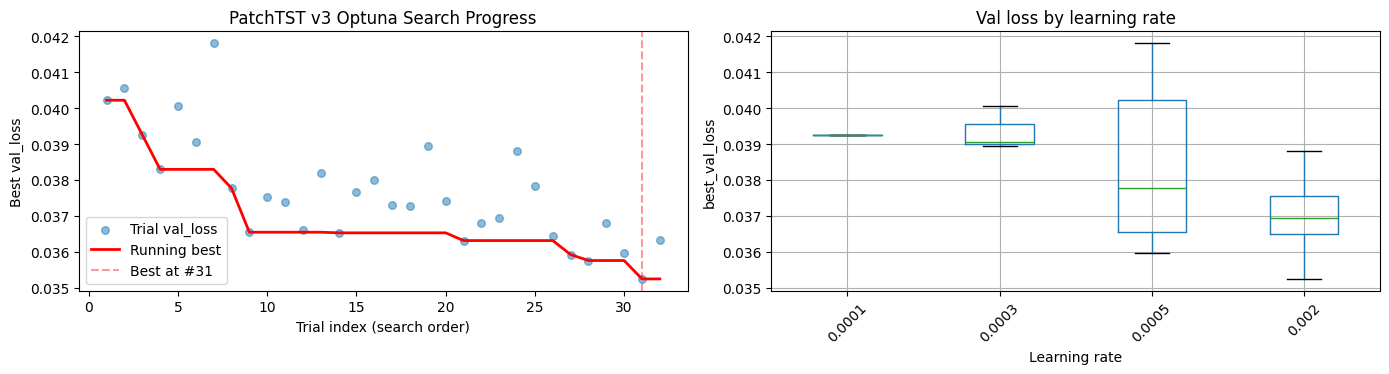

In [60]:
# Search progress chart
results_order = results_df.sort_values("name").reset_index(drop=True)
x = range(1, len(results_order) + 1)
running_best = results_order["best_val_loss"].cummin()
best_idx = int(results_order["best_val_loss"].idxmin()) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.scatter(x, results_order["best_val_loss"], alpha=0.5, s=30, label="Trial val_loss")
ax.plot(x, running_best, color="red", linewidth=2, label="Running best")
ax.axvline(best_idx, color="red", linestyle="--", alpha=0.4, label=f"Best at #{best_idx}")
ax.set_title("PatchTST v3 Optuna Search Progress")
ax.set_xlabel("Trial index (search order)")
ax.set_ylabel("Best val_loss")
ax.legend()

ax = axes[1]
results_df.boxplot(column="best_val_loss", by="lr", ax=ax)
ax.set_title("Val loss by learning rate")
plt.suptitle("")
ax.set_xlabel("Learning rate")
ax.set_ylabel("best_val_loss")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


#### 7.2 Scatter: performance vs training time

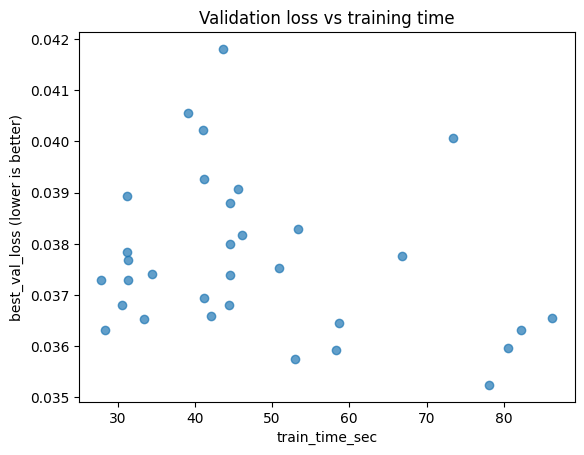

In [61]:
plt.figure()
plt.scatter(results_df["train_time_sec"], results_df["best_val_loss"], alpha=0.7)
plt.title("Validation loss vs training time")
plt.xlabel("train_time_sec")
plt.ylabel("best_val_loss (lower is better)")
plt.show()

#### 7.3 Important Hyperparameters

<Figure size 640x480 with 0 Axes>

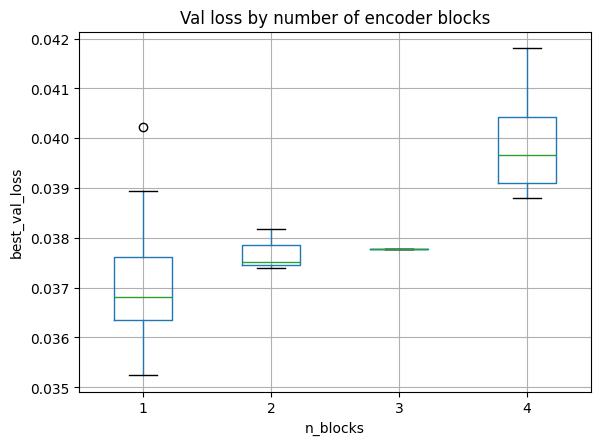

In [62]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="n_blocks")
plt.title("Val loss by number of encoder blocks")
plt.suptitle("")
plt.xlabel("n_blocks")
plt.ylabel("best_val_loss")
plt.show()


##### 7.3.1 By Patch Size

<Figure size 640x480 with 0 Axes>

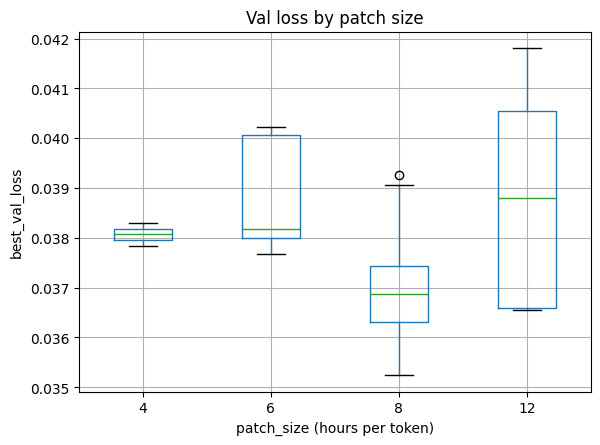

In [63]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="patch_size")
plt.title("Val loss by patch size")
plt.suptitle("")
plt.xlabel("patch_size (hours per token)")
plt.ylabel("best_val_loss")
plt.show()


##### 7.3.2 By Dropout

<Figure size 640x480 with 0 Axes>

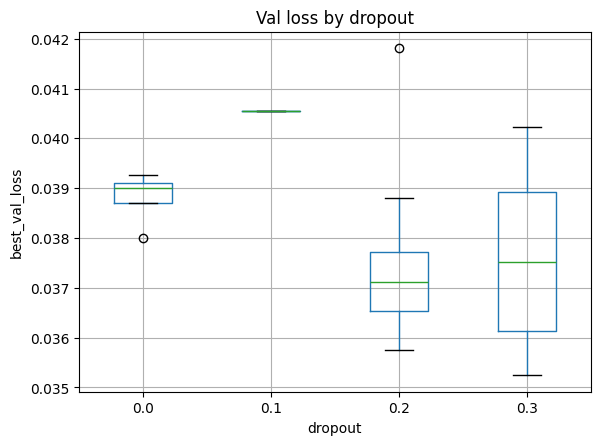

In [64]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="dropout")
plt.title("Val loss by dropout")
plt.suptitle("")
plt.xlabel("dropout")
plt.ylabel("best_val_loss")
plt.show()

##### 7.3.3 By n_heads

<Figure size 640x480 with 0 Axes>

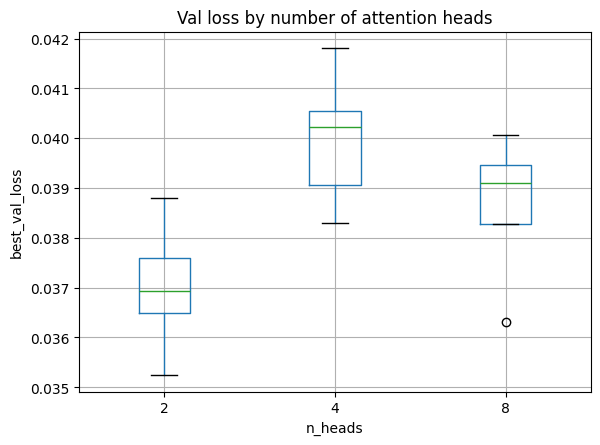

In [65]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="n_heads")
plt.title("Val loss by number of attention heads")
plt.suptitle("")
plt.xlabel("n_heads")
plt.ylabel("best_val_loss")
plt.show()


##### 7.3.4 By d_model

<Figure size 640x480 with 0 Axes>

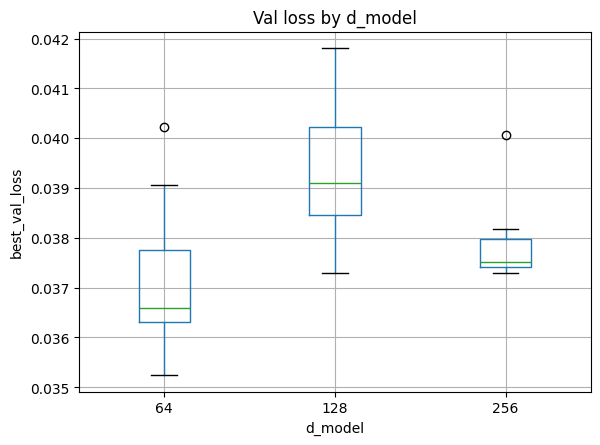

In [66]:
plt.figure()
results_df.boxplot(column="best_val_loss", by="d_model")
plt.title("Val loss by d_model")
plt.suptitle("")
plt.xlabel("d_model")
plt.ylabel("best_val_loss")
plt.show()


## 8. Horizon-wise comparison: baseline vs best PatchTST v3 (°C)

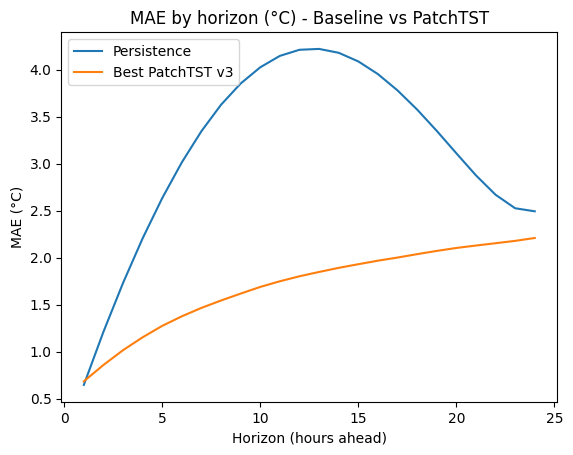

In [68]:
y_pred_persist_c = inverse_scale_target(y_pred_persist, scaler, feat_cols, target_col)

H = y_test.shape[1]
mae_h_p = np.mean(np.abs(y_test_c - y_pred_persist_c), axis=0)
mae_h_t = np.mean(np.abs(y_test_c - y_pred_c),         axis=0)

plt.figure()
plt.plot(range(1, H+1), mae_h_p, label="Persistence")
plt.plot(range(1, H+1), mae_h_t, label="Best PatchTST v3")
plt.title("MAE by horizon (°C) - Baseline vs PatchTST")
plt.xlabel("Horizon (hours ahead)")
plt.ylabel("MAE (°C)")
plt.legend()
plt.show()


### 8.1 Error distribution (residuals) on test (°C)

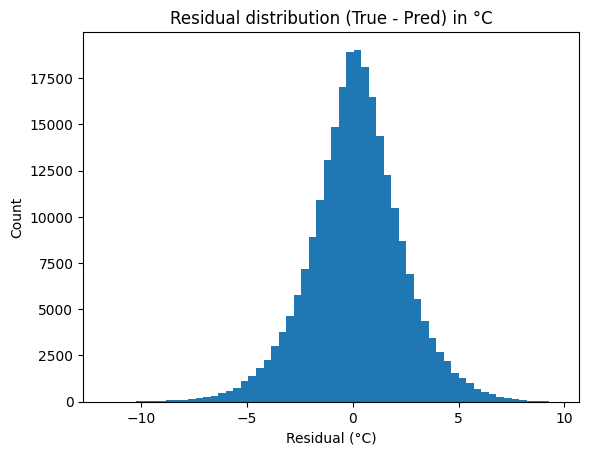

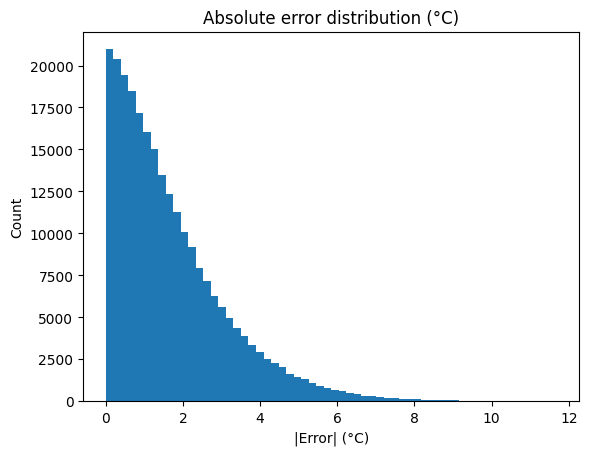

In [69]:
res = (y_test_c - y_pred_c).reshape(-1)

plt.figure()
plt.hist(res, bins=60)
plt.title("Residual distribution (True - Pred) in °C")
plt.xlabel("Residual (°C)")
plt.ylabel("Count")
plt.show()

# Absolute error distribution
abs_err = np.abs(res)
plt.figure()
plt.hist(abs_err, bins=60)
plt.title("Absolute error distribution (°C)")
plt.xlabel("|Error| (°C)")
plt.ylabel("Count")
plt.show()

### 8.2 Plot actual vs predicted for a continuous slice (h=1)

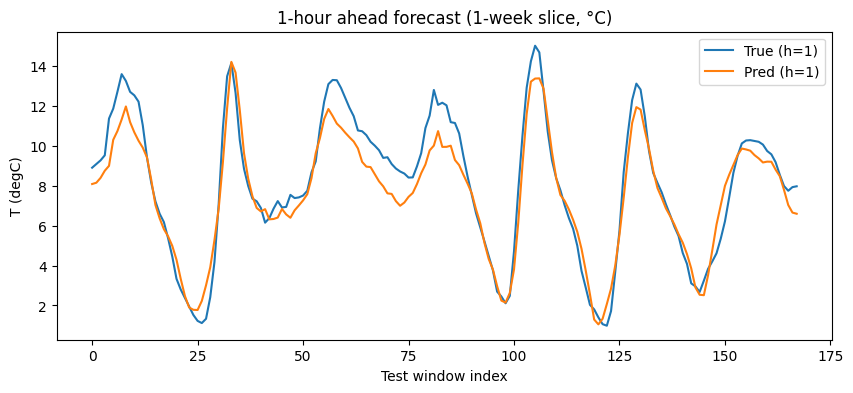

In [70]:
start = 0
n = 7 * 24  # 1 week of windows

y_true_1 = y_test_c[start:start+n, 0]
y_pred_1 = y_pred_c[start:start+n, 0]

plt.figure(figsize=(10,4))
plt.plot(y_true_1, label="True (h=1)")
plt.plot(y_pred_1, label="Pred (h=1)")
plt.title("1-hour ahead forecast (1-week slice, °C)")
plt.xlabel("Test window index")
plt.ylabel("T (degC)")
plt.legend()
plt.show()

### 8.3 Plot 24-hour trajectories for a few examples

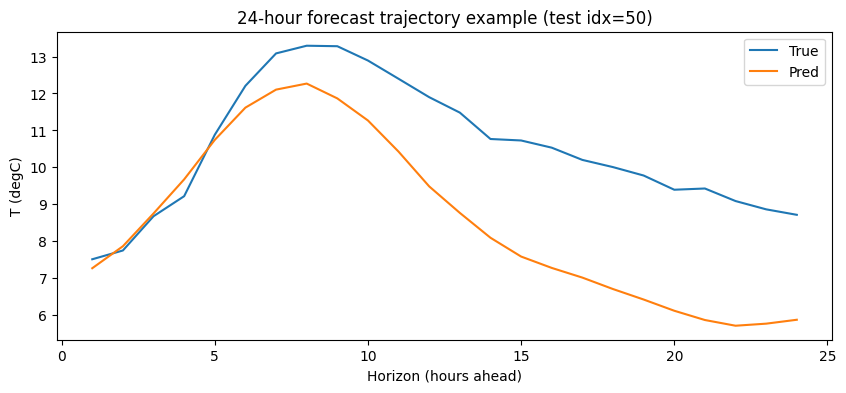

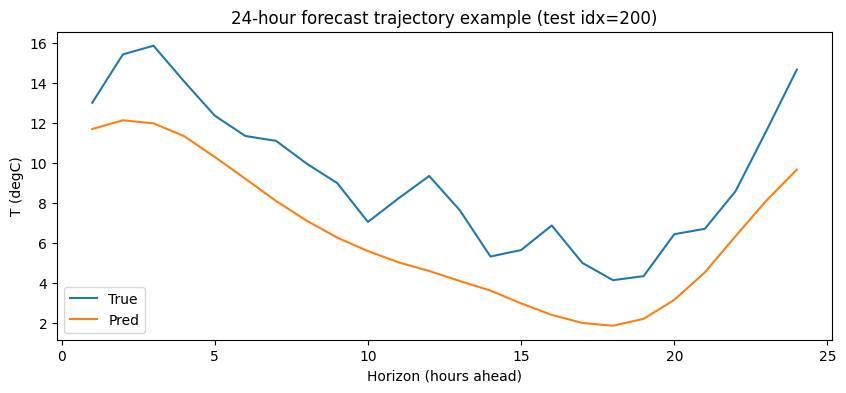

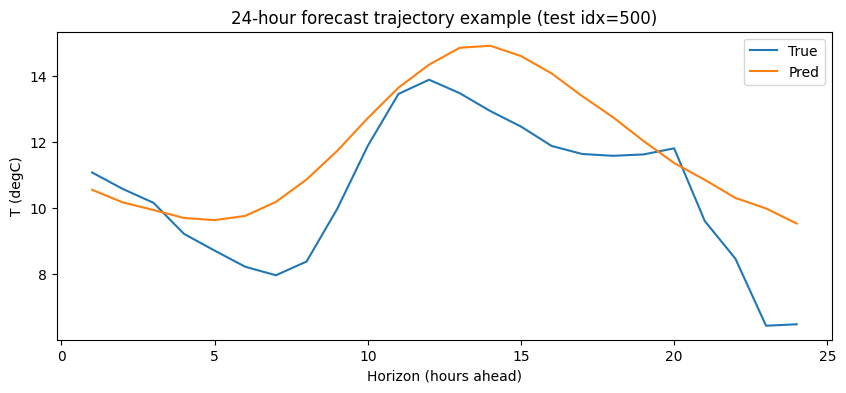

In [71]:
examples = [50, 200, 500]  # pick any indices within test

for i in examples:
    plt.figure(figsize=(10,4))
    plt.plot(range(1, H+1), y_test_c[i], label="True")
    plt.plot(range(1, H+1), y_pred_c[i], label="Pred")
    plt.title(f"24-hour forecast trajectory example (test idx={i})")
    plt.xlabel("Horizon (hours ahead)")
    plt.ylabel("T (degC)")
    plt.legend()
    plt.show()

## 9. Forecasting

/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


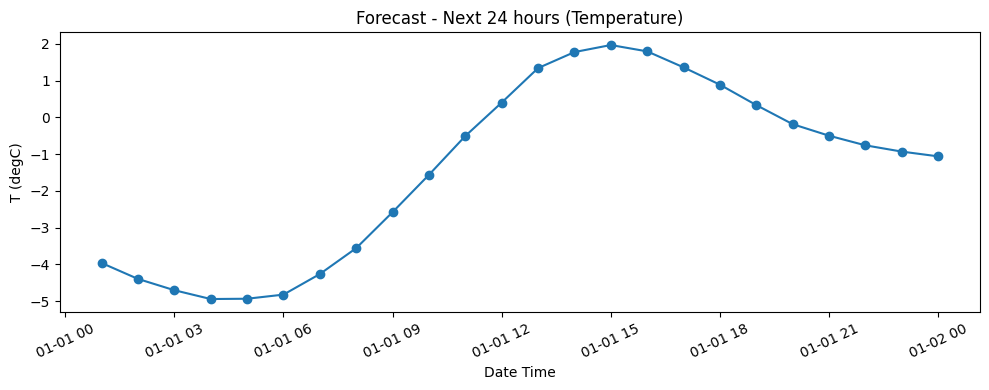

,Date Time,T_forecast_degC
0,2017-01-01 01:00:00,-3.963408
1,2017-01-01 02:00:00,-4.397307
2,2017-01-01 03:00:00,-4.704617
3,2017-01-01 04:00:00,-4.944407
4,2017-01-01 05:00:00,-4.936522
5,2017-01-01 06:00:00,-4.824308
6,2017-01-01 07:00:00,-4.263962
7,2017-01-01 08:00:00,-3.558654
8,2017-01-01 09:00:00,-2.578968
9,2017-01-01 10:00:00,-1.562548


,Date Time,T_forecast_degC
14,2017-01-01 15:00:00,1.970362
15,2017-01-01 16:00:00,1.797666
16,2017-01-01 17:00:00,1.362443
17,2017-01-01 18:00:00,0.890382
18,2017-01-01 19:00:00,0.335321
19,2017-01-01 20:00:00,-0.184277
20,2017-01-01 21:00:00,-0.498361
21,2017-01-01 22:00:00,-0.760287
22,2017-01-01 23:00:00,-0.930763
23,2017-01-02 00:00:00,-1.060291


In [73]:
# 2.1) Build last input window (L hours) from the end of the dataset
df_full = df_work.copy()  # df_work: hourly clean, index=Date Time, columns=features (unscaled)

# If you engineered features during training, apply the same here:
df_full_fe = add_time_features(df_full)

# Keep the same columns and order used in scaling/training
df_full_fe = df_full_fe[feat_cols].copy()

# Take last L rows
last_window = df_full_fe.iloc[-L:].copy()

# Scale
last_window_scaled = scaler.transform(last_window.values)

# Model input shape: (1, L, n_features)
X_last = last_window_scaled.reshape(1, L, len(feat_cols))

# Predict next 24h (scaled)
y_next24_scaled = best_transformer.predict(X_last, verbose=0)  # shape (1, 24)

# Inverse scale to °C
y_next24_c = inverse_scale_target(y_next24_scaled, scaler, feat_cols, target_col).flatten()

# Build future datetime index
last_time = df_full_fe.index[-1]
future_index_24 = pd.date_range(start=last_time + pd.Timedelta(hours=1), periods=H, freq="1h")

# Plot forecast
plt.figure(figsize=(10,4))
plt.plot(future_index_24, y_next24_c, marker="o")
plt.title("Forecast - Next 24 hours (Temperature)")
plt.xlabel("Date Time")
plt.ylabel("T (degC)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# Show as table
forecast_24h = pd.DataFrame({"Date Time": future_index_24, "T_forecast_degC": y_next24_c})
display(forecast_24h.head(10))
display(forecast_24h.tail(10))

### 9.2 5 days Forecasting

In [74]:
def forecast_rolling_5days(df_full_raw, best_model, scaler, feat_cols, target_col, L=120, H=24, days=5, lag_hours=168):
    steps = days * 24  # total future hours
    n_blocks = steps // H

    df_sim = df_full_raw.copy()
    preds_all = []
    last_time = df_sim.index[-1]

    for b in range(n_blocks):
        # Recompute time features over current (growing) df_sim
        df_sim_fe = add_time_features(df_sim)

        # Use last L hours as model input
        X_win = df_sim_fe[feat_cols].iloc[-L:].values
        X_win_s = scaler.transform(X_win).reshape(1, L, len(feat_cols))

        y_block_s = best_model.predict(X_win_s, verbose=0)  # (1, H)
        y_block_c = inverse_scale_target(y_block_s, scaler, feat_cols, target_col).flatten()

        # Future timestamps for this block
        start = last_time + pd.Timedelta(hours=1)
        idx = pd.date_range(start=start, periods=H, freq="1h")

        preds_all.append(pd.DataFrame({"Date Time": idx, "T_forecast_degC": y_block_c}))

        # Seasonal-naive imputation for exogenous features:
        # For each future hour t, use the observed values from lag_hours ago (default: 168h = 7 days).
        # This is physically motivated: atmospheric variables (pressure, humidity, wind)
        # exhibit strong weekly periodicity, making same-hour-last-week a better
        # proxy than freezing the last observed value indefinitely.
        for t, yv in zip(idx, y_block_c):
            lag_time = t - pd.Timedelta(hours=lag_hours)
            if lag_time in df_sim.index:
                new_row = df_sim.loc[[lag_time]].copy()
            else:
                new_row = df_sim.iloc[-1:].copy()  # fallback if lag not in history
            new_row.index = [t]
            new_row[target_col] = yv  # temperature always from model prediction
            df_sim = pd.concat([df_sim, new_row])

        last_time = idx[-1]

    return pd.concat(preds_all, ignore_index=True)

forecast_5d = forecast_rolling_5days(df_work, best_transformer, scaler, feat_cols, target_col, L=L, H=H, days=5)
display(forecast_5d.head())
display(forecast_5d.tail())

/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/logus/env/iscte/taap_p3/.venv_taap_p3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: U

,Date Time,T_forecast_degC
0,2017-01-01 01:00:00,-3.963408
1,2017-01-01 02:00:00,-4.397307
2,2017-01-01 03:00:00,-4.704617
3,2017-01-01 04:00:00,-4.944407
4,2017-01-01 05:00:00,-4.936522


,Date Time,T_forecast_degC
115,2017-01-05 20:00:00,2.526379
116,2017-01-05 21:00:00,2.187286
117,2017-01-05 22:00:00,1.929475
118,2017-01-05 23:00:00,1.808642
119,2017-01-06 00:00:00,1.690133


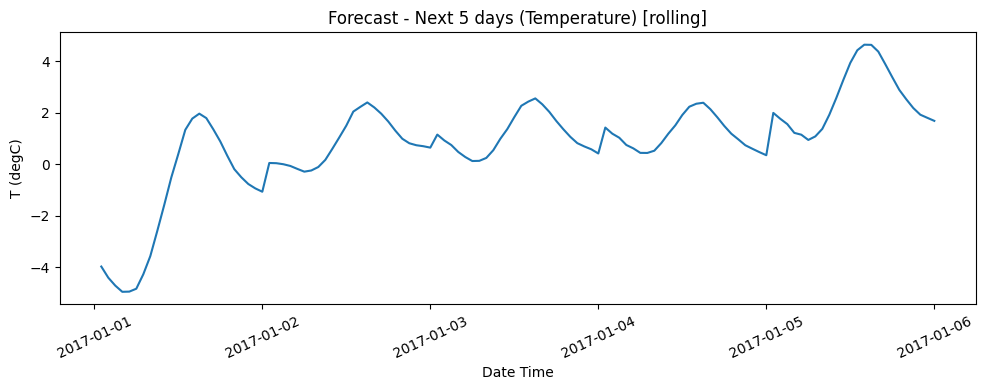

In [75]:
plt.figure(figsize=(10,4))
plt.plot(forecast_5d["Date Time"], forecast_5d["T_forecast_degC"])
plt.title("Forecast - Next 5 days (Temperature) [rolling]")
plt.xlabel("Date Time")
plt.ylabel("T (degC)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()